# ADR severity binary classification
* https://anonymous.4open.science/r/EMNLP-CC48/README.md
* Hierarchical Pharmacovigilance Retrieval with MedDRA-Guided Evidence Aggregation

# From Nishant, what is baseline and RAG in the context of this project?
* off-the-shelf LLM only (base)
* RAG: LLM + Retrieval Augmented Generation (RAG) #finetune LLM on 2 quarterly releases 

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [290]:
from sentence_transformers import SentenceTransformer
import pickle, os, sys, time, gc, json, collections
import pandas as pd
import lancedb, lance
import optuna
from lance.vector import vec_to_table
import copy
# from lance.vector import vec_to_table
import numpy as np
import struct
import pyarrow as pab
import pyarrow.dataset
from tqdm import trange, tqdm
import itertools
#from utils.funcs import *
import torch
from torch.utils.data import TensorDataset, DataLoader,random_split
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from sklearn.metrics import (average_precision_score, roc_curve,
roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import catboost as cb

#from torchmetrics.text.bert import BERTScore
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (hamming_loss, jaccard_score, recall_score, precision_score, 
                             f1_score)

device = "cuda" if torch.cuda.is_available() else "cpu"

import warnings
warnings.filterwarnings("ignore")

In [ ]:
adr = pickle.load(open("./adr_trn_new.pkl", "rb"))
#adr.reset_index(names = ["id"], inplace = True)
print(adr.shape)
#adr.id = adr.id.astype(str)
adr.head()

(3387476, 9)


,id,inst,outcome,uni_code,pt,caseid,yr_qtr,outc_code,Severity
0,0,"{""patient"":""{""age"": ""59.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""arterial thrombosis; drug interaction;...",DE,arterial thrombosis; drug interaction; haemorr...,31231172,2020q3,DE; HO,YES
1,1,"{""patient"":""{""age"": ""46.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""anaemia; dermatitis; ecchymosis"", ""uni...",OT,anaemia; dermatitis; ecchymosis,32427281,2020q3,OT,NO
2,2,"{""patient"":""{""age"": ""72.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""blood pressure decreased; rash erythem...",RI,blood pressure decreased; rash erythematous,37847331,2020q3,RI,NO
3,3,"{""patient"":""{""age"": ""34.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""blister; dermatitis; lip disorder; muc...",DE,blister; dermatitis; lip disorder; mucosal ero...,32030921,2020q3,LT; DE,YES
4,4,"{""patient"":""{""age"": ""79.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""conjunctivitis; mouth ulceration; oral...",DE,conjunctivitis; mouth ulceration; oral mucosal...,32138152,2020q3,LT; DE,YES


In [ ]:
 adr_severity_idx = adr[adr.uni_code != "NA"].index

In [ ]:
del adr
gc.collect()

0

In [ ]:
# map adr Severity to embeds
adr_severity = adr.Severity.iloc[adr_severity_idx,] 

In [ ]:
adr_severity = [0 if i == "NO" else "YES" for i in adr_severity]

In [ ]:
collections.Counter(adr_severity)

Counter({0: 2054090, 1: 450511})

In [ ]:
adr_severity = [1 if i == "YES" else 0 for i in adr_severity]

In [ ]:
adr_embed = pickle.load(open("bge_m3_embeddings.pkl", "rb"))

In [ ]:
adr_embed = adr_embed[adr_severity_idx,:]

In [ ]:
adr_embed.shape

(2504601, 1024)

In [ ]:
pickle.dump((adr_embed, adr_severity), open("adr_severity_all.pkl", "wb"))

In [ ]:

a = np.array([[1, 2, 3],
              [4, 5, 6]])
b = np.array([[7,8,9],
              [10,11,12]])

# Stack along axis 0 (default): arrays become rows
np.concatenate((a,b), axis = 0).shape

(4, 3)

In [ ]:
tt = pd.concat([tt, pd.Series(np.where(tt.index.isin(["DE", "LT"]), 1, 0), index=tt.index)], axis=1).reset_index()

In [ ]:
tt.columns = ["uni_code", "count", "severity"]
tt

,uni_code,count,severity
0,HO,1040973,0
1,OT,899837,0
2,NA,882875,0
3,DE,260389,1
4,LT,190122,1
5,DS,85875,0
6,RI,20566,0
7,CA,6839,0


In [ ]:
adr["Severity"] = np.where(adr.uni_code.isin(["DE", "LT"]), "YES","NO")

In [ ]:
# #load oot w/o NA
oot = pickle.load(open("./adr_oot_new.pkl", "rb"))
oot.reset_index(drop = True, inplace = True)
print(oot.shape)
oot.head(2)

(118953, 8)


,caseid,pt,yr_qtr,uni_code,inst,outcome,outc_code,severity
0,243847721,genital swelling; near death experience; weigh...,2024q4,HO,"{""patient"":""{""age"": ""55.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""genital swelling; near death experienc...",HO; OT,NO
1,237436793,drug ineffective; abdominal pain,2024q4,HO,"{""patient"":""{""age"": ""65.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""drug ineffective; abdominal pain"", ""un...",HO; OT,NO


In [ ]:
oot.outc_code.value_counts()[:20]

outc_code
OT            46789
HO            23352
HO; OT        15459
OT; HO         5701
DE             2643
LT             2173
DE; OT         1788
DS             1753
LT; OT         1334
HO; LT         1329
HO; LT; OT     1237
DS; OT         1167
DE; HO; OT      721
HO; RI          664
OT; DE          655
DE; HO          649
RI              599
LT; HO          504
OT; LT          503
OT; DS          392
Name: count, dtype: int64

# evaluation of BGE_m3 finetuned model 

In [ ]:
embed_mdl_summary = pickle.load(open("embed_mdl_summary.pkl", "rb"))

In [193]:
embed_mdl_summary

,model,mean_rank,hit@1,hit@3,hit@5,mrr@5,ndcg@5
1,./bge_m3,3.233667,0.238000,0.555333,0.860000,0.440489,0.543316
3,./medembed_base,3.223667,0.223333,0.562333,0.870000,0.435694,0.542273
2,./medembed_large,3.067667,0.258667,0.601667,0.876333,0.466828,0.567639
4,./medembed_small,2.954667,0.285667,0.626000,0.893000,0.490467,0.589598
0,./bge_m3_4adr,1.303333,0.806333,0.973667,0.997333,0.887967,0.915830


In [ ]:
# Convert to LaTeX string
latex_str = embed_mdl_summary.style.format(precision=2).hide(axis="index").to_latex()

\begin{tabular}{lrrrrrr}
model & mean_rank & hit@1 & hit@3 & hit@5 & mrr@5 & ndcg@5 \\
./bge_m3 & 3.23 & 0.24 & 0.56 & 0.86 & 0.44 & 0.54 \\
./medembed_base & 3.22 & 0.22 & 0.56 & 0.87 & 0.44 & 0.54 \\
./medembed_large & 3.07 & 0.26 & 0.60 & 0.88 & 0.47 & 0.57 \\
./medembed_small & 2.95 & 0.29 & 0.63 & 0.89 & 0.49 & 0.59 \\
./bge_m3_4adr & 1.30 & 0.81 & 0.97 & 1.00 & 0.89 & 0.92 \\
\end{tabular}



# evalute LLM on validation set

In [197]:
qwen_base_val = pd.read_csv("qwen_0.8b_base_unicode_preds.csv")

In [215]:
qwen_base_val.head()

,index,caseid,inst,severity,pred_label_id,pred_label,pred_confidence
0,9404,245431911,"{""patient"":""{""age"": ""63.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.998793
1,53267,249351721,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.996827
2,78531,1918203414,"{""patient"":""{""age"": ""81.0"", ""age_cod"": ""yr"", ""...",YES,1,1,0.998299
3,74397,251096431,"{""patient"":""{""age"": ""34.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.999614
4,15899,246026821,"{""patient"":""{""age"": ""66.0"", ""age_cod"": ""yr"", ""...",YES,1,1,0.994358


In [222]:
# group by index column and get pred_label with highest pred_confidence
idx_max = qwen_base_val.groupby("index")["pred_confidence"].idxmax()
best_per_idx = qwen_base_val.loc[idx_max].reset_index()

# keep only desired columns
best_per_idx = best_per_idx[["index", "pred_label", "pred_confidence"]]


In [223]:
best_per_idx.pred_label.value_counts()

pred_label
1    15712
0       20
Name: count, dtype: int64

In [318]:
def llmEval(csv_file):
    _all_oot = pd.read_csv(csv_file)

    # group by index column and get pred_label with highest pred_confidence
    idx_max = _all_oot.groupby("index")["pred_confidence"].idxmax()
    all_best_per_idx = _all_oot.loc[idx_max].reset_index()

    # keep only desired columns
    all_best_per_idx = all_best_per_idx[["index", "severity", "pred_label", "pred_confidence"]]

    # convert severity to 0/1
    all_best_per_idx.severity = [0 if i == "NO" else 1 for i in all_best_per_idx.severity]

    # get recall, precission and F1 score 
    _all_precision = precision_score(all_best_per_idx.severity, all_best_per_idx.pred_label) 
    _all_recall = recall_score(all_best_per_idx.severity, all_best_per_idx.pred_label) 
    _all_f1 = f1_score(all_best_per_idx.severity, all_best_per_idx.pred_label)
    _all_accuray = accuracy_score(all_best_per_idx.severity, all_best_per_idx.pred_label)
    _all_auc = roc_auc_score(all_best_per_idx.severity, all_best_per_idx.pred_label)

    print("all_accuracy: ", _all_accuray, "\n"
      "all_precision: ", _all_precision, "\n"
      "all_recall: ", _all_recall, "\n"
      "all_f1: ", _all_f1, "\n"
      "all_auc: ",_all_auc)   


In [276]:
qwen_all_oot = pd.read_csv("qwen_0.8b_all_unicode_preds.csv")

In [277]:
qwen_all_oot.head()

,index,caseid,inst,severity,pred_label_id,pred_label,pred_confidence
0,51003,254524131,"{""patient"":""{""age"": ""29.0"", ""age_cod"": ""yr"", ""...",NO,0,0,0.966663
1,77696,251360361,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO,0,0,0.899121
2,77701,251402711,"{""patient"":""{""age"": ""62.0"", ""age_cod"": ""yr"", ""...",NO,0,0,0.932453
3,77702,251402981,"{""patient"":""{""age"": ""80.0"", ""age_cod"": ""yr"", ""...",NO,0,0,0.600657
4,77704,251403011,"{""patient"":""{""age"": ""17.0"", ""age_cod"": ""yr"", ""...",YES,0,0,0.903294


In [278]:
# group by index column and get pred_label with highest pred_confidence
idx_max = qwen_all_oot.groupby("index")["pred_confidence"].idxmax()
all_best_per_idx = qwen_all_oot.loc[idx_max].reset_index()

# keep only desired columns
all_best_per_idx = qwen_all_oot[["index", "severity", "pred_label", "pred_confidence"]]

In [279]:
all_best_per_idx.severity = [0 if i == "NO" else 1 for i in all_best_per_idx.severity]

In [280]:
all_best_per_idx.pred_label.value_counts()

pred_label
0    352931
1     41055
Name: count, dtype: int64

In [284]:
# get recall, precission and F1 score 
qwen_all_precision = precision_score(all_best_per_idx.severity, all_best_per_idx.pred_label) 
qwen_all_recall = recall_score(all_best_per_idx.severity, all_best_per_idx.pred_label) 
qwen_all_f1 = f1_score(all_best_per_idx.severity, all_best_per_idx.pred_label)
qwen_all_accuray = accuracy_score(all_best_per_idx.severity, all_best_per_idx.pred_label)
qwen_all_auc = roc_auc_score(all_best_per_idx.severity, all_best_per_idx.pred_label)

In [286]:
print("qwen_all_accuracy: ", qwen_all_accuray, "\n"
      "qwen_all_precision: ", qwen_all_precision, "\n"
      "qwen_all_recall: ", qwen_all_recall, "\n"
      "qwen_all_f1: ", qwen_all_f1, "\n"
      "qwen_all_auc: ",qwen_all_auc)

qwen_all_accuracy:  0.8413141583711097 
qwen_all_precision:  0.6100109609061015 
qwen_all_recall:  0.3500062890444845 
qwen_all_f1:  0.4447996589940324 
qwen_all_auc:  0.6501747305571705


In [ ]:
llmEval("qwen_0.8b_base_unicode_preds.csv")

all_accuracy:  0.8082936271590232 
all_precision:  0.27391021470396876 
all_recall:  0.059886201991465146 
all_f1:  0.09828411345862029 
all_auc:  0.5131692177515794


In [360]:
llama_all = pd.read_csv("llama_3b_all_unicode_preds.csv")

In [362]:
llama_all.head()

,inst,severity,pred_label_id,pred_label,pred_confidence
0,"{""patient"":""{""age"": ""29.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.573678
1,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.758153
2,"{""patient"":""{""age"": ""62.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.511717
3,"{""patient"":""{""age"": ""80.0"", ""age_cod"": ""yr"", ""...",NO,1,1,0.648911
4,"{""patient"":""{""age"": ""17.0"", ""age_cod"": ""yr"", ""...",YES,1,1,0.844922


In [363]:
llama_all = pd.concat([pd.Series(tst_idx_lst), llama_all], axis = 1)

In [364]:
llama_all.rename(columns = {0:"index"}, inplace = True)

In [365]:
llama_all.to_csv("llama_3b_all_preds_new.csv", index = True)

In [366]:
llmEval("llama_3b_all_preds_new.csv")

all_accuracy:  0.2520101250744491 
all_precision:  0.16712651606598838 
all_recall:  0.8334527733983087 
all_f1:  0.2784228292355941 
all_auc:  0.4818543917413225


In [370]:
llama_base = pd.read_csv("llama_base_preds.csv")

In [371]:
llama_base = pd.concat([pd.Series(tst_idx_lst), llama_base], axis = 1)

In [372]:
llama_base.rename(columns = {0:"index"}, inplace = True)
llama_base.to_csv("llama_3b_base_new.csv", index = True)

In [373]:
llmEval("llama_3b_base_new.csv")

all_accuracy:  0.8159618820726623 
all_precision:  0.26167209554831705 
all_recall:  0.03454206679088433 
all_f1:  0.061028108381868826 
all_auc:  0.5070666455086508


In [ ]:
#oot = pd.merge(oot, oot_outc, left_on="caseid", right_on = "primaryid", how = "left")

In [ ]:
#oot_outc.drop_duplicates(subset = "primaryid", inplace = True)

In [ ]:
trn_inst_embed = pickle.load(open("bge_m3_embeddings.pkl", "rb"))

In [ ]:
del trn_inst_embed
gc.collect()

0

In [ ]:
(vect_ids, vect_scores) = pickle.load(open("oot_vect_id_score_lst.pkl", "rb"))
(bm25_ids, bm25_scores) = pickle.load(open("bm25_oot_top5_id_score_503.pkl", "rb"))

In [ ]:
#pickle.dump((bm25_inst_embeds, vect_inst_embeds), open("bm25_vect_top5_inst_embeds.pkl", "wb"))
(bm25_inst_embeds, vect_inst_embeds) = pickle.load(open("bm25_vect_top5_inst_embeds.pkl", "rb"))

In [ ]:
# del bm25_inst_embeds
# gc.collect()

In [ ]:
# get bm25 inst embeddings on bm25_ids mapped to adr ids
bm25_inst_embeds = []
for id_lst in tqdm(bm25_ids):
    embed_lst = []
    for caseid in id_lst:
        embed_lst.append(trn_inst_embed[int(caseid)])
    bm25_inst_embeds.append(embed_lst)

100%|██████████| 118953/118953 [00:00<00:00, 141365.41it/s]


In [ ]:
vect_inst_embeds = []
for id_lst in tqdm(vect_ids):
    vect_lst = []
    for caseid in id_lst:
        vect_lst.append(trn_inst_embed[int(caseid)])
    vect_inst_embeds.append(vect_lst)

100%|██████████| 118953/118953 [00:00<00:00, 539370.85it/s]


In [ ]:
#pickle.dump((bm25_inst_embeds, vect_inst_embeds), open("bm25_vect_top5_inst_embeds.pkl", "wb"))

In [ ]:
bm25_inst_embeds, vect_inst_embeds = pickle.load(open("bm25_vect_top5_inst_embeds.pkl", "rb"))

In [ ]:
# get adr inst of top5 BM25 and top5 vector retrievals
id_to_inst = dict(zip(adr.id, adr.inst))

bm25_top5_inst = []
for id_lst in tqdm(bm25_ids):
    inst_lst = []
    for caseid in id_lst:
        inst = id_to_inst.get(caseid)
        inst_lst.append(inst)
    bm25_top5_inst.append(inst_lst)

100%|██████████| 118953/118953 [00:01<00:00, 103650.72it/s]


In [ ]:
vect_top5_inst = []
for id_lst in tqdm(vect_ids):
    inst_lst = []
    for caseid in id_lst:
        inst = id_to_inst.get(caseid)
        inst_lst.append(inst)
    vect_top5_inst.append(inst_lst)

100%|██████████| 118953/118953 [00:00<00:00, 226736.81it/s]


In [ ]:
bm25_top5_inst[0]

['{"patient":"{"age": "65.0", "age_cod": "yr", "gndr_cod": "m", "wt": "77.8", "wt_cod": "kg"}","treatment":"{"drugname": "pradaxa", "route": "oral", "dose": "300 mg"}; {"drugname": "indomethacin.", "route": "oral", "dose": "75 mg"}; {"drugname": "diltiazem", "route": "oral", "dose": "300 mg"}; {"drugname": "dronedarone", "route": "oral", "dose": "400 mg"}; {"drugname": "oxycodone-acetaminophen", "route": "oral", "dose": "nan"}; {"drugname": "rosuvastatin", "route": "oral", "dose": "10 mg"}","indi_pt":"atrial fibrillation; gout; hypertension; atrial fibrillation; pain; hypercholesterolaemia"}',
 '{"patient":"{"age": "25.0", "age_cod": "yr", "gndr_cod": "f", "wt": "83.9", "wt_cod": "kg"}","treatment":"{"drugname": "phentermine hydrochloride", "route": nan, "dose": nan}; {"drugname": "nuvaring", "route": nan, "dose": "unk"}; {"drugname": "yaz", "route": nan, "dose": "unk"}; {"drugname": "drospirenone and ethinyl estradiol", "route": nan, "dose": "unk"}; {"drugname": "contraceptives nos", 

In [ ]:
pickle.dump(bm25_top5_inst, open("./oot_bm25_top5_inst.pkl", "wb"))
pickle.dump(vect_top5_inst, open("./oot_vect_top5_inst.pkl", "wb"))

#####################################################################
# Get multi-class vectors for train and oot       
#####################################################################

In [ ]:
oot.head(2)

,caseid,pt,yr_qtr,uni_code,inst,outcome,outc_code
0,243847721,genital swelling; near death experience; weigh...,2024q4,HO,"{""patient"":""{""age"": ""55.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""genital swelling; near death experienc...",HO; OT
1,237436793,drug ineffective; abdominal pain,2024q4,HO,"{""patient"":""{""age"": ""65.0"", ""age_cod"": ""yr"", ""...","{""pt"": ""drug ineffective; abdominal pain"", ""un...",HO; OT


In [ ]:
(vect_ids, vect_scores) = pickle.load(open("oot_vect_id_score_lst.pkl", "rb"))
(bm25_ids, bm25_scores) = pickle.load(open("bm25_oot_top5_id_score_503.pkl", "rb"))

# prepare oot set for LLM evaluation 

In [ ]:
len(oot_indices)

15732

In [ ]:
len(bm25_ids)

118953

In [ ]:
bm25_ids_val = [bm25_ids[ids] for ids in val_indices]
vect_ids_val = [vect_ids[ids] for ids in val_indices]

In [ ]:
len(bm25_ids_val[0])

5

In [ ]:
id_to_inst = dict(zip(adr.id[adr.uni_code != "NA"], 
                      adr.inst[adr.uni_code != "NA"])) #excluding NA in uni_code

id_to_severity = dict(zip(adr.id[adr.uni_code != "NA"], 
                      adr.Severity[adr.uni_code != "NA"])) #excluding NA in uni_code

In [ ]:
del adr
gc.collect()

539

In [249]:
tst_idx_lst[:5]

[51003, 77696, 77701, 77702, 77704]

In [250]:
b_rows = []
for idx in tqdm(tst_idx_lst):
    id_lst = bm25_ids[idx]
    for caseid in id_lst:
        inst = id_to_inst.get(caseid)
        # preserve original behavior: skip if no instance found
        if not inst:
            continue
        sev = id_to_severity.get(caseid)
        b_rows.append({"index": idx, "caseid": caseid, "inst": inst, "severity": sev})

oot_bm25_df = pd.DataFrame(b_rows)

100%|██████████| 40296/40296 [00:00<00:00, 95255.79it/s]


In [251]:
v_rows = []
for idx in tqdm(tst_idx_lst):
    id_lst = vect_ids[idx]
    for caseid in id_lst:
        inst = id_to_inst.get(caseid)
        # preserve original behavior: skip if no instance found
        if not inst:
            continue
        sev = id_to_severity.get(caseid)
        v_rows.append({"index": idx, "caseid": caseid, "inst": inst, "severity": sev})

oot_vect_df = pd.DataFrame(v_rows)

100%|██████████| 40296/40296 [00:00<00:00, 99285.19it/s] 


In [252]:
oot_vect_df.shape

(176845, 4)

In [253]:
# get query inst and severity
query_oot_df = oot.loc[tst_idx_lst, ["caseid","inst", "severity"]].reset_index()
query_oot_df.head()

,index,caseid,inst,severity
0,51003,254524131,"{""patient"":""{""age"": ""29.0"", ""age_cod"": ""yr"", ""...",NO
1,77696,251360361,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO
2,77701,251402711,"{""patient"":""{""age"": ""62.0"", ""age_cod"": ""yr"", ""...",NO
3,77702,251402981,"{""patient"":""{""age"": ""80.0"", ""age_cod"": ""yr"", ""...",NO
4,77704,251403011,"{""patient"":""{""age"": ""17.0"", ""age_cod"": ""yr"", ""...",YES


In [254]:
oot_inst_severity = pd.concat([query_oot_df, oot_vect_df, oot_vect_df])

In [255]:
print(oot_inst_severity.shape)
oot_inst_severity.head()

(393986, 4)


,index,caseid,inst,severity
0,51003,254524131,"{""patient"":""{""age"": ""29.0"", ""age_cod"": ""yr"", ""...",NO
1,77696,251360361,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO
2,77701,251402711,"{""patient"":""{""age"": ""62.0"", ""age_cod"": ""yr"", ""...",NO
3,77702,251402981,"{""patient"":""{""age"": ""80.0"", ""age_cod"": ""yr"", ""...",NO
4,77704,251403011,"{""patient"":""{""age"": ""17.0"", ""age_cod"": ""yr"", ""...",YES


In [256]:
#pickle.dump(val_inst_severity, open("val_inst_severity.pkl", "wb"))
pickle.dump(oot_inst_severity, open("oot_inst_severity.pkl", "wb"))

In [ ]:
# import collections
# cnt_dict = collections.Counter(non_na_list)
# cnt_dict

In [ ]:
# # get keys sorted by sort count     
# [key for key, value in sorted(cnt_dict.items(), key=lambda x: x[1], reverse=True)]

In [ ]:
# topK recall

topk_hit = {}
for idx, item in enumerate(dict(cnt_dict)):
    topk_hit[idx] = item in oot.outc_code[0].split("; ")


In [ ]:
topk_hit

{0: True, 1: True}

In [ ]:
len(bm25_outc_lbl_top5)

118953

In [ ]:
# # For each oot case, use top 5 labels from bm25_outc_lbl_top5 and vect_outc_lbl_top5 to 
# # generate a list of outcome code based on majority vote 
# oot['outc_lst_order'] = [[]] * len(oot) 

# for i in trange(len(oot)):
#     bm25_lbls_i = bm25_outc_lbl_top5[i]
#     vect_lbls_i = vect_outc_lbl_top5[i]
#     lbl_lst = [i for sub_i in bm25_lbls_i + vect_lbls_i for i in sub_i if i != "nan"]
#     if len(lbl_lst) > 0:
#         cnt_dict = collections.Counter(lbl_lst)
#         #majority_lbls = [lbl for lbl, count in lbl_count.items() if count > 1] # majority vote    
#         oot.at[i, 'outc_lst_order'] = [key for key, value in sorted(cnt_dict.items(), key=lambda x: x[1], reverse=True)]
#     else:
#         oot.at[i, 'outc_lst_order'] = []

In [ ]:
# # find hit@topk: if top k labels in oot.outc_code split by "; " is in topk of oot.outc_lst_order, then it's a hit
# top1_hit = top3_hit = top5_hit = 0
# for idx, item in enumerate(oot.outc_lst_order):
#     oout_code = oot.outc_code[idx].split("; ")
#     for k in [1, 3, 5]:
#         if k == 1:
#             top1_hit += len(set(oout_code) & set(item[:k])) >= min(k, len(oout_code))
#         elif k == 3:
#             top3_hit += len(set(oout_code) & set(item[:k])) >= min(k, len(oout_code))
#         elif k == 5:
#             top5_hit += len(set(oout_code) & set(item[:k])) >= min(k, len(oout_code))

In [ ]:
#print(top1_hit/oot.shape[0], top3_hit/oot.shape[0], top5_hit/oot.shape[0])

# binary classification model features and labels
* features:
  - bm25_score,
  - dense_score,
  - cosine(query_emb, neighbor_query_emb),
  - cosine(query_outcome_emb, neighbor_outcome_emb)
* labels:
    - severity (YES/NO)

In [45]:
oot_embed = oot_X_raw[:,0,:]

In [47]:
pickle.dump(oot_embed, open("oot_inst_embed.pkl", "wb"))

In [48]:
oot_embed = pickle.load(open("oot_inst_embed.pkl", "rb"))
oot_embed.shape

(118953, 1024)

In [16]:
(bm25_pt_embeds, vect_pt_embeds) = pickle.load(open("bm25_vect_top5_pt_embeds.pkl", "rb"))

In [146]:
# del bm25_inst_embeds
# gc.collect()

In [18]:
# get trn index from oot
trn_idx_lst = oot[oot["yr_qtr"].isin(["2024q4", "2025q1"])].index.tolist()

In [ ]:
len(trn_idx_lst) #training size

78657

In [ ]:
oot_trn_y = [0 if i == "NO" else 1 for i in oot.severity]

In [ ]:
oot_trn_severity = [oot_trn_y[i] for i in trn_idx_lst]

In [45]:
collections.Counter(oot_trn_severity)

Counter({0: 64763, 1: 13894})

In [29]:
# get training embeds and binary 0/1
pickle.dump((oot_embed[trn_idx_lst,:], oot_trn_severity), open("oot_severity_trn.pkl", "wb"))

In [31]:
mv oot_severity_trn.pkl ./psc

In [ ]:
tst_idx_lst = oot[oot["yr_qtr"].isin(["2025q2"])].index.tolist()

In [28]:
# get inst and uni_code of adr_id in bm25 adn vect 
bm25_retrieved_inst = []
bm25_retrieved_uni_code= []
vect_retrieved_inst = []
vect_retrieved_uni_code = []
for idx  in tqdm(trn_idx_lst):
    bm25_ids_ = [int(i) for i in bm25_ids[idx]]
    bm25_retrieved_inst += [adr.inst[j] for j in bm25_ids_ if adr.uni_code[j] != "NA"]
    bm25_retrieved_uni_code += [adr.Severity[j] for j in bm25_ids_ if adr.uni_code[j] != "NA"]

    vect_ids_ = [int(i) for i in vect_ids[idx]]
    vect_retrieved_inst += [adr.inst[j] for j in vect_ids_ if adr.uni_code[j] != "NA"]
    vect_retrieved_uni_code += [adr.Severity[j] for j in vect_ids_ if adr.uni_code[j] != "NA"]

100%|██████████| 78657/78657 [00:56<00:00, 1401.96it/s]


In [29]:
retrived_inst = bm25_retrieved_inst + vect_retrieved_inst
retrived_uni_code = bm25_retrieved_uni_code + vect_retrieved_uni_code

In [30]:
retrieved_map_df = pd.DataFrame({'inst': retrived_inst, 'severity': retrived_uni_code})

In [31]:
retrieved_map_df.shape

(638354, 2)

In [32]:
oot_trn_df = oot.loc[trn_idx_lst, ["inst", "severity"]].copy()
oot_trn_df.shape

(78657, 2)

In [33]:
trn_full = pd.concat([oot_trn_df, retrieved_map_df])
trn_full.shape

(717011, 2)

In [34]:
trn_full.head()

,inst,severity
0,"{""patient"":""{""age"": ""55.0"", ""age_cod"": ""yr"", ""...",NO
1,"{""patient"":""{""age"": ""65.0"", ""age_cod"": ""yr"", ""...",NO
2,"{""patient"":""{""age"": ""82.0"", ""age_cod"": ""yr"", ""...",NO
3,"{""patient"":""{""age"": ""42.0"", ""age_cod"": ""yr"", ""...",NO
4,"{""patient"":""{""age"": ""61.0"", ""age_cod"": ""yr"", ""...",YES


In [ ]:
pickle.dump(trn_full, open("oot_trn_full.pkl", "wb")) #including training and validation set

In [14]:
pickle.dump((trn_idx_lst, tst_idx_lst), open("oot_train_test_indices.pkl", "wb"))

In [3]:
trn_idx_lst, tst_idx_lst = pickle.load(open("oot_train_test_indices.pkl", "rb"))

In [8]:
trn_df = oot.loc[trn_idx_lst, ["inst", "severity"]].copy()
trn_df.head()

,inst,severity
0,"{""patient"":""{""age"": ""55.0"", ""age_cod"": ""yr"", ""...",NO
1,"{""patient"":""{""age"": ""65.0"", ""age_cod"": ""yr"", ""...",NO
2,"{""patient"":""{""age"": ""82.0"", ""age_cod"": ""yr"", ""...",NO
3,"{""patient"":""{""age"": ""42.0"", ""age_cod"": ""yr"", ""...",NO
4,"{""patient"":""{""age"": ""61.0"", ""age_cod"": ""yr"", ""...",YES


In [240]:
oot_tst_df = oot.loc[tst_idx_lst, ["caseid", "inst", "severity"]].copy()
oot_tst_df.shape

(40296, 3)

In [241]:
oot_tst_df.head()

,caseid,inst,severity
51003,254524131,"{""patient"":""{""age"": ""29.0"", ""age_cod"": ""yr"", ""...",NO
77696,251360361,"{""patient"":""{""age"": ""71.0"", ""age_cod"": ""yr"", ""...",NO
77701,251402711,"{""patient"":""{""age"": ""62.0"", ""age_cod"": ""yr"", ""...",NO
77702,251402981,"{""patient"":""{""age"": ""80.0"", ""age_cod"": ""yr"", ""...",NO
77704,251403011,"{""patient"":""{""age"": ""17.0"", ""age_cod"": ""yr"", ""...",YES


# get OOT inference set

In [243]:
pickle.dump(oot_tst_df, open("inference_input.pkl", "wb"))
#oot_tst_df = pickle.load(open("inference_input.pkl", "rb"))

In [4]:
#trn_input = pd.concat([oot_trn_df, retrieved_map_df])

In [5]:
# trn_input = trn_input[trn_input.uni_code != "NA"]
# trn_input.shape

In [236]:
#pickle.dump(trn_df, open("finetuned_input.pkl", "wb"))
trn_df = pickle.load(open("finetuned_input.pkl", "rb"))

In [ ]:
trn_df.shape # only query 

(78657, 2)

In [ ]:
#pickle.dump(trn_input, open("finetuned_input_full.pkl", "wb"))
pickle.dump(oot_trn_df, open("finetuned_input.pkl", "wb"))

In [49]:
oot_idx_lst = oot[oot["yr_qtr"] > "2025q1"].index.tolist()
len(oot_idx_lst) #testing size

40296

# get validation preds

In [ ]:
# prepare val inference set: each val has 11 strings, 1 for query and 10 for retrievals


In [65]:
def calculate_metrics(pred_csv, model_name = ""):
    # get LLM prediciton metrics
    _preds = pd.read_csv(pred_csv)
    obs = [0 if x =='NO' else 1 for x in _preds.severity]
    pred = _preds.pred_label
    f1 = f1_score(obs, pred)
    recall = recall_score(obs, pred)
    precision = precision_score(obs, pred)
    accuray = accuracy_score(obs, pred)
    roc_auc = roc_auc_score(obs, pred)
    df = pd.DataFrame([{"Model":model_name, "Accuray": accuray,
                         "F1 Score":f1, "Recall": recall, "Precision": precision,
                         "ROC AUC": roc_auc}])
    # plot ROC curve with pred_confidence
    fpr, tpr, _ = roc_curve(obs, _preds.pred_confidence)
    plt.plot(fpr, tpr, label=model_name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print(df)
    return df

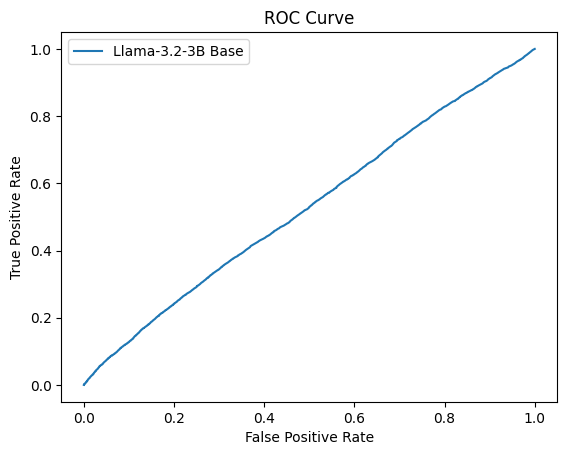

               Model   Accuray  F1 Score    Recall  Precision   ROC AUC
0  Llama-3.2-3B Base  0.733522  0.206356  0.200086   0.213032  0.522655


In [56]:
l3b_base = calculate_metrics("llama_3b_base_preds.csv", "Llama-3.2-3B Base")

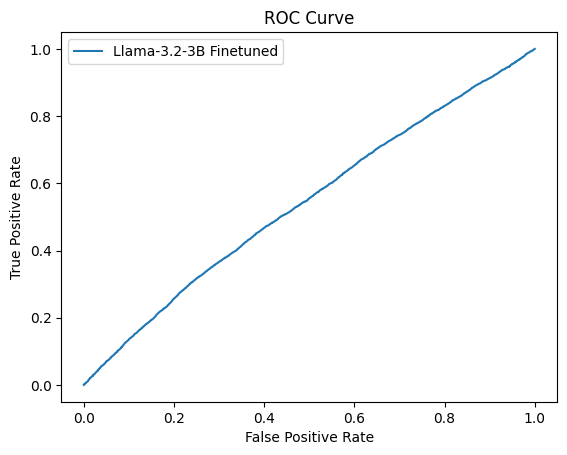

                    Model  Accuray  F1 Score    Recall  Precision   ROC AUC
0  Llama-3.2-3B Finetuned  0.25201  0.278423  0.833453   0.167127  0.481854


In [57]:
l3b_all = calculate_metrics("llama_3b_all_unicode_preds.csv", "Llama-3.2-3B Finetuned")

# inference of 0.8b Qwen on unicode retrieved data

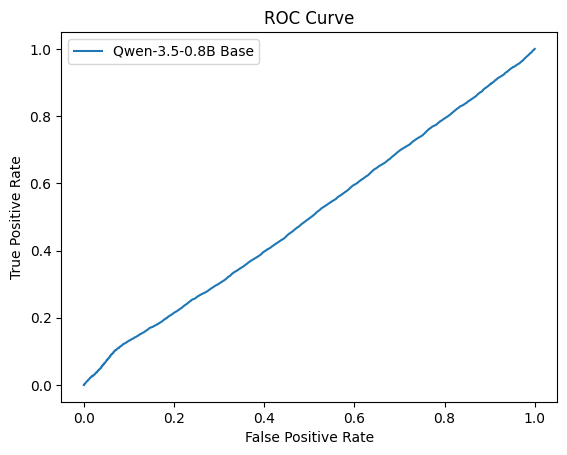

                Model  Accuray  F1 Score   Recall  Precision   ROC AUC
0  Qwen-3.5-0.8B Base  0.20749  0.282859  0.90268   0.167705  0.482298


In [58]:
qwen_Base = calculate_metrics("qwen_0.8b_base_preds.csv", "Qwen-3.5-0.8B Base")

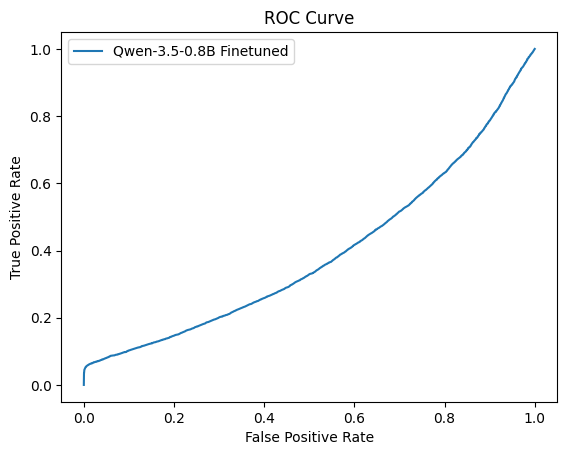

                     Model   Accuray  F1 Score    Recall  Precision   ROC AUC
0  Qwen-3.5-0.8B Finetuned  0.828445  0.349365  0.266017   0.508772  0.606117


In [ ]:
qwen_all = calculate_metrics("qwen_0.8b_all_unicode_preds.csv", "Qwen-3.5-0.8B Finetuned")

In [44]:
 ft_metrics = pd.concat([l3b_base, l3b_all, qwen_Base, qwen_all], ignore_index = True)

In [45]:
ft_metrics.to_csv("ft_metrics.csv", index = False)

In [36]:
#q08b_obs, q08b_pred = calculate_metrics("qwen_0.8b_unicode_preds.csv")

# Prepare model input
* get attention weights
* get rank score of query prob and outcome prob 

# get attention weights
attn_weights = softmax(query_emb @ neighbor_emb.T)

In [142]:
def softmax(x, axis=-1):
    # Subtract max for numerical stability to prevent overflow (nan errors)
    kw = dict(axis=axis, keepdims=True)
    e_x = np.exp(x - np.max(x, **kw))
    return e_x / np.sum(e_x, **kw)

In [ ]:
oot_bm25_q_att_wt = []
oot_vect_q_att_wt = []
# oot_bm25_o_att_wt = []
# oot_vect_o_att_wt = []
for i in trange(len(bm25_inst_embeds)):
    #get attention weight for each of the top5 bm25 and vect retrieved instances based on cosine similarity with oot instance embed
    bm25_q_embed_i = np.array(bm25_inst_embeds[i])
    vect_q_embed_i = np.array(vect_inst_embeds[i])

    bm25_o_embed_i = np.array(bm25_pt_embeds[i])
    vect_o_embed_i = np.array(vect_pt_embeds[i])

    # get prob between oot inst embed and each of the top5 
    bm25_q_att = softmax(oot_q_embeds[i].reshape(1, -1) @ bm25_q_embed_i.T)[0]
    vect_q_att = softmax(oot_q_embeds[i].reshape(1, -1) @ vect_q_embed_i.T)[0]

    # # get cosine similarity between oot outcome embed and each of the top5 
    # bm25_o_att = softmax(oot_pt_embeds[i].reshape(1, -1) @ bm25_o_embed_i.T)[0]
    # vect_o_att = softmax(oot_pt_embeds[i].reshape(1, -1) @ vect_o_embed_i.T)[0]    

    oot_bm25_q_att_wt.append(bm25_q_att)
    oot_vect_q_att_wt.append(vect_q_att)
    # oot_bm25_o_att_wt.append(bm25_o_att)
    # oot_vect_o_att_wt.append(vect_o_att)

100%|██████████| 118953/118953 [00:06<00:00, 17228.60it/s]


In [375]:
# save query attention weight
#pickle.dump((oot_bm25_q_att_wt, oot_vect_q_att_wt), open("oot_q_att_wt.pkl", "wb"))
oot_bm25_q_att_wt, oot_vect_q_att_wt = pickle.load(open("oot_q_att_wt.pkl", "rb"))

In [376]:
oot_bm25_q_att_wt[0]

array([0.2170967 , 0.17214061, 0.20861274, 0.18806076, 0.21408918],
      dtype=float32)

In [26]:
# get retrieval_context = sum of attn_weight_i * neighbor_features_i
bm25_q_prob = []
vect_q_prob = []
for idx in trange(len(bm25_inst_embeds)):
    b_prob_i = np.sum([att_wt * neighbor_feat for att_wt, neighbor_feat in 
                                zip(oot_bm25_q_att_wt[idx], bm25_inst_embeds[idx])], axis=0)
    
    v_prob_i = np.sum([att_wt * neighbor_feat for att_wt, neighbor_feat in 
                                zip(oot_vect_q_att_wt[idx], vect_inst_embeds[idx])], axis=0)
    
    bm25_q_prob.append(b_prob_i)
    vect_q_prob.append(v_prob_i)

100%|██████████| 118953/118953 [00:03<00:00, 31962.55it/s]


In [ ]:
bm25_q_prob[0]

array([-0.00331055,  0.01069972, -0.01469897, ...,  0.03323555,
       -0.00494954,  0.00129864], shape=(1024,), dtype=float32)

In [18]:
# save query probability vector
# pickle.dump((bm25_q_prob, vect_q_prob), open("oot_q_prob.pkl", "wb"))
bm25_q_prob, vect_q_prob = pickle.load(open("oot_q_prob.pkl", "rb"))

In [112]:
len(bm25_q_prob)

118953

In [ ]:
#oot_q_embeds = pickle.load(open("oot_inst_embed.pkl", "rb"))

In [ ]:
oot_X = np.concatenate([oot_q_embeds, bm25_q_prob, vect_q_prob], axis = 1) 

In [ ]:
def build_case_tokens(case_idx):
    """
    One case -> (3, 1024) with per-input normalization.
    Normalizes each embedding independently before stacking.
    """
    q_emb = oot_q_embeds[case_idx]        # (1024,)
    b_emb_1 = bm25_q_prob[case_idx]            # (1024,)
    v_emb_2 = vect_q_prob[case_idx]            # (1024,)  
    
    # L2 normalize each embedding independently
    q_emb_norm = q_emb / (np.linalg.norm(q_emb) + 1e-8)
    b_emb_1_norm = b_emb_1 / (np.linalg.norm(b_emb_1) + 1e-8)
    v_emb_2_norm = v_emb_2 / (np.linalg.norm(v_emb_2) + 1e-8)
    
    # Stack normalized embeddings: (3, 1024)
    oot_X_idx = np.stack([q_emb_norm, b_emb_1_norm, v_emb_2_norm], axis=0)
    
    return oot_X_idx

In [ ]:
oot_x_list = [build_case_tokens(i) for i in range(len(bm25_q_prob))]
oot_X_raw = np.stack(oot_x_list, axis=0).astype(np.float32)
print(f"raw x_1hot shape: {oot_X_raw.shape}")

raw x_1hot shape: (118953, 6, 1024)


In [26]:
pickle.dump(oot_X_raw, open("./hybrid_oot_X_new.pkl", "wb"))

In [22]:
oot_X_raw = pickle.load(open("./hybrid_oot_X_new.pkl", "rb"))

In [ ]:
oot_X_raw = oot_X_raw[:,:3, :]

In [25]:
oot_X_raw.shape

(118953, 3, 1024)

# Recall@K
* Measures the fraction of all relevant information in the knowledge base that the system successfully retrieved

In [ ]:
# get bm25 and vect top5 candidates' uni_code from adr based on caseid as string,
# and map to integers for each oot instance

# Create a mapping from caseid (as string) to severity
id_to_severity = dict(zip(adr.id.astype(str), adr.Severity))

# Extract and map BM25 top5 candidates' severity codes to integers
bm25_severity = []
for id_lst in tqdm(bm25_ids):
    code_lst = []
    for caseid in id_lst:
        severity = id_to_severity.get(str(caseid))
        if severity:
            code_lst.append(severity)
    bm25_severity.append(code_lst)

# Extract and map vector top5 candidates' severity codes to integers
vect_severity = []
for id_lst in tqdm(vect_ids):
    code_lst = []
    for caseid in id_lst:
        severity = id_to_severity.get(str(caseid))
        if severity:
            code_lst.append(severity)
    vect_severity.append(code_lst) 


100%|██████████| 118953/118953 [00:00<00:00, 244623.50it/s]


In [ ]:
# convert severity "YES"/"NO" to binary 1/0 for both bm25 and vect candidates
def severity_to_binary(severity_lst):
    return [1 if s == "YES" else 0 for s in severity_lst]

bm25_severity_nbr = [severity_to_binary(lst) for lst in bm25_severity]
vect_severity_nbr = [severity_to_binary(lst) for lst in vect_severity]

In [ ]:
bm25_severity_nbr[0]

[0, 0, 0, 0, 1]

In [ ]:
class HybridEvidenceTransformer(nn.Module):
    """
    Transformer-based model for binary classification over retrieved evidence tokens.
    
    Input:  (B, 3, 1024) — 3 retrieved context tokens
    Output: (B, num_classes) — logits
    """
    
    def __init__(self, token_dim, num_classes, d_model=256, nhead=8, 
                 num_layers=2, dim_feedforward=512, dropout=0.1, max_tokens=3):
        super().__init__()
        
        # 1. Project tokens to model dimension
        self.in_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # 2. Learnable positional embeddings
        self.pos_emb = nn.Parameter(torch.zeros(1, max_tokens, d_model))
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)
        
        # 3. Multi-head self-attention layers (core difference!)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,            
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        
        # 4. Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x, key_padding_mask=None):
        h = self.in_proj(x)                           # (B, 10, d_model)
        h = h + self.pos_emb[:, :h.size(1), :]        # Add positional info
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)  # Self-attention
        pooled = h.mean(dim=1)                        # Mean pooling
        return self.head(pooled)


In [28]:
trn_idx_lst, tst_idx_lst = pickle.load(open("oot_train_test_indices.pkl", "rb")) 

In [29]:
oot_X_raw[[trn_idx_lst],:,:].shape

(1, 78657, 3, 1024)

In [56]:
x_trn_tensor = torch.tensor(oot_X_raw[[trn_idx_lst],:,:].reshape(len(trn_idx_lst), 3, 1024)
                            , dtype=torch.float32)

x_tst_tensor = torch.tensor(oot_X_raw[[tst_idx_lst],:,:].reshape(len(tst_idx_lst), 3, 1024)
                            , dtype=torch.float32)

#pickle.dump(_1hot_norm_stats, open("oot_top5_1hot_norm_stats.pkl", "wb"))
print(f"normalized x_trn_tensor: {x_trn_tensor.shape}")
print(f"normalized x_tst_tensor: {x_tst_tensor.shape}")
#print(f"saved stats -> oot_top5_1hot_norm_stats.pkl")

normalized x_trn_tensor: torch.Size([78657, 3, 1024])
normalized x_tst_tensor: torch.Size([40296, 3, 1024])


# fit model with retrieval scores ONLY

In [98]:
# Convert each value to string to handle any numpy array wrapping
oot_severity_nbr = [0 if i == "NO" else 1 for i in oot.severity]
y_trn = torch.tensor([oot_severity_nbr[i] for i in trn_idx_lst], dtype=torch.long)
y_tst = torch.tensor([oot_severity_nbr[i] for i in tst_idx_lst], dtype=torch.long)

In [32]:
x_trn_tensor.shape, y_trn.shape

(torch.Size([78657, 3, 1024]), torch.Size([78657]))

In [ ]:
#pickle.dump((x_trn_tensor, x_tst_tensor, y_trn, y_tst), open("x_y_trn_tst_cls_tensor.pkl", "wb"))
(x_trn_tensor, x_tst_tensor, y_trn, y_tst) = pickle.load(open("x_y_trn_tst_cls_tensor.pkl", "rb"))

In [58]:
x_trn_tensor.shape

torch.Size([78657, 3, 1024])

## Retrieval baselines: weighted vote & restricted softmax

Fast multiclass predictors on `x_code_1hot_tensor` `(N, 10, TOKEN_DIM)` — compare to `HybridEvidenceTransformer` before training heavier models.

In [ ]:
np.unique(oot_severity_nbr, return_counts=True) #5:1

(array([0, 1]), array([98082, 20871]))

In [34]:
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

dataset_1hot = TensorDataset(x_trn_tensor, y_trn) 

In [37]:
# 5-fold CV
n = len(dataset_1hot)
train_size = int(0.8 * n)
val_size = n - train_size
train_ds, val_ds = random_split(dataset_1hot, [train_size, val_size])

#set batch size of 2048 to use GPU
train_loader_1hot = DataLoader(train_ds, batch_size=2048, shuffle=True, num_workers=2, pin_memory=True)
val_loader_1hot = DataLoader(val_ds, batch_size=2048, shuffle=False, num_workers=2, pin_memory=True)

In [40]:
pickle.dump((train_loader_1hot, val_loader_1hot), open("severity_binary_loader.pkl", "wb"))

In [ ]:
train_loader_1hot, val_loader_1hot = pickle.load(open("severity_binary_loader.pkl", "rb"))

In [246]:
val_indices = val_ds.indices

In [ ]:
pickle.dump(val_indices, open("val_inference_index.pkl", "wb"))

In [ ]:
TOKEN_DIM = train_ds[0][0].shape[-1]
print(f"Token dimension: {TOKEN_DIM}")
NUM_CLASSES = 2

Token dimension: 1024


In [66]:
class BalancedBinaryCrossEntropy(nn.Module):
    def __init__(self, pos_weight, max_pos_weight: float = 100.0, max_logit: float = 50.0):
        super().__init__()
        # store as float scalar (CPU) and keep clamp limits
        self.register_buffer("_pos_weight_scalar", torch.tensor(float(pos_weight), dtype=torch.float32))
        self.max_pos_weight = float(max_pos_weight)
        self.max_logit = float(max_logit)

    def forward(self, logits, targets):
        # ensure shapes: logits (B,1) and targets float (B,1)
        if logits.dim() == 1:
            logits = logits.unsqueeze(1)
        targets = targets.float()
        if targets.dim() == 1:
            targets = targets.unsqueeze(1)

        # move pos_weight to logits device and clamp to avoid extreme scaling
        pos_w = torch.clamp(self._pos_weight_scalar.to(logits.device), max=self.max_pos_weight)

        # sanitize inputs to avoid NaN/Inf making it to the stable loss
        if not torch.isfinite(logits).all():
            logits = torch.nan_to_num(logits, nan=0.0, posinf=self.max_logit, neginf=-self.max_logit)
        # also clamp magnitude to avoid overflow in intermediate ops
        logits = torch.clamp(logits, -self.max_logit, self.max_logit)

        if not torch.isfinite(targets).all():
            targets = torch.nan_to_num(targets, nan=0.0, posinf=1.0, neginf=0.0)

        # BCEWithLogits accepts pos_weight as 1D tensor of length C (here 1)
        pos_weight_tensor = pos_w.view(1)

        loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=pos_weight_tensor.to(logits.device),
            reduction="mean",
        )
        return loss

In [58]:
class HybridRAGBinaryModel(nn.Module):
    """
    Simplified binary classification model for (B, 3, 1024) input.
    
    Input:  (B, 3, 1024) — 3 retrieved context tokens (normalized embeddings)
    Output: (B, 1) logit for binary classification (0/1 severity)
    """
    def __init__(self, input_features=1024, 
                 hidden_dim=768, 
                 dropout=0.2, 
                 num_heads=4):
        super().__init__()
        self.hidden_dim = int(hidden_dim)

        # per-token projection: (1024,) -> (hidden_dim,)
        self.token_proj = nn.Linear(input_features, hidden_dim)

        # two-layer per-token feed-forward
        self.token_ff = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # lightweight self-attention across the 3 tokens
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(hidden_dim)

        # classification head: mean pool + mlp -> logit
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        """
        Args:
            x: (B, 3, 1024) tensor of 3 normalized embeddings per case
        
        Returns:
            logits: (B, 1) tensor of raw logits for binary classification
        """
        # Ensure shape (B, 3, 1024)
        if x.dim() == 2:
            x = x.view(x.size(0), 3, -1)

        # Project tokens to hidden dimension: (B, 3, 1024) -> (B, 3, hidden_dim)
        proj = self.token_proj(x)
        
        # Apply token-wise feedforward: (B, 3, hidden_dim) -> (B, 3, hidden_dim)
        proj = self.token_ff(proj)

        # Self-attention across 3 tokens: (B, 3, hidden_dim) -> (B, 3, hidden_dim)
        attn_out, _ = self.attn(proj, proj, proj)
        proj = self.attn_norm(proj + attn_out)  # residual + norm

        # Mean pool over 3 tokens: (B, 3, hidden_dim) -> (B, hidden_dim)
        pooled = proj.mean(dim=1)

        # Classification head: (B, hidden_dim) -> (B, 1)
        logits = self.head(pooled)
        
        return logits


In [67]:
# build criterion on training portion only to avoid data leakage
pos_weight = (y_trn.detach().cpu().numpy() == 0).sum() / ((y_trn.detach().cpu().numpy() == 1).sum() + 1e-6)
print(f"Positive weight: {pos_weight}")
criterion = BalancedBinaryCrossEntropy(pos_weight)

Positive weight: 4.661220670457664


In [162]:
def tune_binary_threshold_recall_with_precision_constraint(
    y_true, probs, min_precision=0.50, max_precision=0.85, thresholds=None
):
    if thresholds is None:
        thresholds = np.arange(0.08, 0.91, 0.01)

    def band_distance(p):
        if p < min_precision:
            return min_precision - p
        if p > max_precision:
            return p - max_precision
        return 0.0

    best_threshold = 0.5
    best_rec = -1.0
    best_prec = 0.0
    valid_rows = []
    rows = []

    for t in thresholds:
        pred = (probs >= t).astype(float)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        rows.append((t, prec, rec))

        if min_precision <= prec <= max_precision:
            valid_rows.append((t, prec, rec))
            if rec > best_rec:
                best_threshold, best_prec, best_rec = float(t), prec, rec

    if valid_rows:
        return best_threshold, best_prec, best_rec, valid_rows

    best_threshold, best_prec, best_rec = max(
        rows, key=lambda row: (row[1], row[2])
    )
    print(
        f"⚠ No threshold in precision band [{min_precision}, {max_precision}]; "
        f"using max-precision fallback: t={best_threshold:.3f}, "
        f"prec={best_prec:.4f}, rec={best_rec:.4f}"
    )
    return float(best_threshold), best_prec, best_rec, rows

In [2]:
# # Train HybridRAGBinaryModel with early stopping (patience=5)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Instantiate model
# hybrid_rag_model = HybridRAGBinaryModel(
#     input_features=1024,
#     hidden_dim=768,
#     dropout=0.2,
#     num_heads=4
# ).to(device)

# print(f"HybridRAGBinaryModel parameters: {sum(p.numel() for p in hybrid_rag_model.parameters() if p.requires_grad):,}")
# print(f"Device: {device}\n")

# # Optimizer and scheduler
# optimizer = torch.optim.AdamW(hybrid_rag_model.parameters(), lr=2e-4, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
# )

# # Training hyperparameters
# num_epochs = 50
# patience = 5
# best_val_rec = -1.0
# best_val_acc = 0.0
# best_threshold = 0.5
# patience_counter = 0
# best_state = None
# history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

# CKPT_PATH = "hybrid_rag_binary_model.pth"

# @torch.no_grad()
# def _collect_val_probs(model, loader):
#     """Collect validation probabilities and true labels."""
#     model.eval()
#     y_true, y_prob = [], []
#     for x_batch, y_batch in loader:
#         x_batch = x_batch.to(device)
#         logits = model(x_batch)
#         y_prob.append(torch.sigmoid(logits).cpu().numpy().reshape(-1))
#         y_true.append(np.asarray(y_batch, dtype=np.float32).reshape(-1))
#     return np.concatenate(y_true), np.concatenate(y_prob)

# def _metrics_at_threshold(y_true, y_prob, threshold):
#     """Compute accuracy and recall at given threshold."""
#     y_pred = (y_prob >= threshold).astype(np.int64)
#     return {
#         "acc": accuracy_score(y_true, y_pred),
#         "rec": recall_score(y_true, y_pred, zero_division=0),
#     }

# print("=" * 80)
# print("TRAINING HYBRID RAG BINARY MODEL (Recall-based early stopping, patience=5)")
# print("=" * 80 + "\n")

# for epoch in range(1, num_epochs + 1):
#     # Training phase
#     hybrid_rag_model.train()
#     train_loss = train_correct = train_total = 0.0

#     for x_batch, y_batch in tqdm(train_loader_1hot, desc=f"Epoch {epoch} - Train", leave=False):
#         x_batch = x_batch.to(device)
#         y_batch = torch.as_tensor(y_batch, dtype=torch.float32, device=device).unsqueeze(1)

#         # Sanitize inputs
#         if torch.isnan(x_batch).any() or torch.isinf(x_batch).any():
#             x_batch = torch.nan_to_num(x_batch, nan=0.0, posinf=1e6, neginf=-1e6)

#         optimizer.zero_grad(set_to_none=True)
#         logits = hybrid_rag_model(x_batch)

#         # Skip if logits contain NaN/Inf
#         if torch.isnan(logits).any() or torch.isinf(logits).any():
#             print("⚠ Skipping batch: logits contain NaN/Inf")
#             continue

#         loss = criterion(logits, y_batch)

#         # Skip if loss not finite
#         if not torch.isfinite(loss):
#             print("⚠ Skipping batch: non-finite loss")
#             continue

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(hybrid_rag_model.parameters(), max_norm=1.0)
#         optimizer.step()

#         bs = x_batch.size(0)
#         train_loss += loss.item() * bs
#         train_correct += ((torch.sigmoid(logits) > 0.5).long() == y_batch.long()).sum().item()
#         train_total += bs

#     train_loss /= max(train_total, 1)
#     train_acc = train_correct / max(train_total, 1)

#     # Validation phase
#     hybrid_rag_model.eval()
#     val_loss = val_correct = val_total = 0.0
#     with torch.no_grad():
#         for x_batch, y_batch in tqdm(val_loader_1hot, desc=f"Epoch {epoch} - Val", leave=False):
#             x_batch = x_batch.to(device)
#             y_batch = torch.as_tensor(y_batch, dtype=torch.float32, device=device).unsqueeze(1)
#             logits = hybrid_rag_model(x_batch)
#             loss = criterion(logits, y_batch)
#             bs = x_batch.size(0)
#             val_loss += loss.item() * bs
#             val_correct += ((torch.sigmoid(logits) > 0.5).long() == y_batch.long()).sum().item()
#             val_total += bs

#     val_loss /= max(val_total, 1)
#     val_acc = val_correct / max(val_total, 1)

#     # Collect validation probs and tune threshold
#     y_val, val_probs = _collect_val_probs(hybrid_rag_model, val_loader_1hot)

#     # Use MUCH stricter precision band [0.3, 0.6] to prevent degenerate solutions
#     tuned_t, tuned_prec, val_rec, valid_rows = tune_binary_threshold_recall_with_precision_constraint(
#     y_val, val_probs,
#     min_precision=0.3,
#     max_precision=0.6,
#     thresholds=np.arange(0.10, 0.91, 0.01),
#     )
#     if not valid_rows:
#         # Emergency fallback: use F1-based threshold instead
#         print(f"⚠ No valid threshold found; falling back to F1 optimization")
#         tuned_t, best_f1 = tune_binary_threshold_f1(y_val, val_probs, 
#                                                      thresholds=np.arange(0.25, 0.71, 0.05))
#         tuned_prec = precision_score(y_val, (val_probs >= tuned_t).astype(float), zero_division=0)
#         val_rec = recall_score(y_val, (val_probs >= tuned_t).astype(float), zero_division=0)
   
    
#     tuned_acc = accuracy_score(y_val, (val_probs >= tuned_t).astype(np.int64))
    
#     # thresh_grid = np.arange(0.15, 0.61, 0.05)
#     # val_rec = 0.0
#     # tuned_t = 0.5
#     # for t in thresh_grid:
#     #     y_pred = (val_probs >= t).astype(np.int64)
#     #     rec = recall_score(y_val, y_pred, zero_division=0)
#     #     if rec > val_rec:
#     #         val_rec = rec
#     #         tuned_t = float(t)
#     # tuned_acc = accuracy_score(y_val, (val_probs >= tuned_t).astype(np.int64))
#     # val_f1 = 0.0
#     # tuned_t = 0.5
#     # for t in thresh_grid:
#     #     m = _metrics_at_threshold(y_val, val_probs, t)
#     #     if m["f1"] > val_f1:
#     #         val_f1 = m["f1"]
#     #         tuned_t = float(t)
#     #tuned_acc = _metrics_at_threshold(y_val, val_probs, tuned_t)["acc"]

#     history["train_loss"].append(train_loss)
#     history["train_acc"].append(train_acc)
#     history["val_loss"].append(val_loss)
#     history["val_acc"].append(val_acc)
#     history["val_f1"].append(val_rec)

#     scheduler.step(val_rec)
#     lr = optimizer.param_groups[0]["lr"]

#     print(
#         f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#         f"Val Loss: {val_loss:.4f} | Val Acc@0.5: {val_acc:.4f} | Val Recall@t*: {val_rec:.4f} "
#         f"(t*={tuned_t:.2f}, acc={tuned_acc:.4f}) | LR: {lr:.2e}"
#     )

#     # Early stopping with patience=5
#     if val_rec > best_val_rec:
#         best_val_rec = val_rec
#         best_val_acc = tuned_acc
#         best_threshold = tuned_t
#         patience_counter = 0
#         best_state = {k: v.detach().cpu().clone() for k, v in hybrid_rag_model.state_dict().items()}
#         torch.save(best_state, CKPT_PATH)
#         print(f"  ✓ Best val recall improved to {val_rec:.4f} (tuned acc {tuned_acc:.4f}), model saved")
#     else:
#         patience_counter += 1
#         print(f"  ⚠ No improvement ({patience_counter}/{patience})")
#         if patience_counter >= patience:
#             print(f"\n✓ Early stopping at epoch {epoch} (no recall improvement for {patience} epochs)")
#             break

# # Load best state
# if best_state is not None:
#     hybrid_rag_model.load_state_dict(best_state)

# hybrid_rag_model.best_threshold = best_threshold
# print(f"\n✓ Training completed. Best val recall: {best_val_rec:.4f} | tuned acc: {best_val_acc:.4f} | threshold: {best_threshold:.2f}")

# # Save training history
# pickle.dump(history, open("hybrid_rag_binary_history.pkl", "wb"))
# print("✓ Training history saved to 'hybrid_rag_binary_history.pkl'")

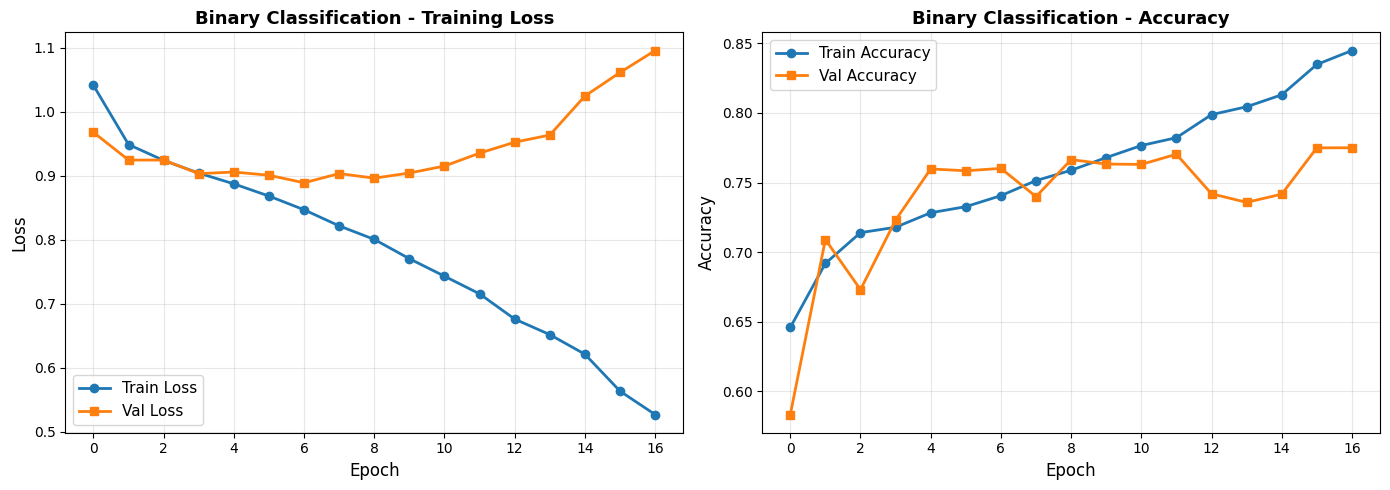

In [47]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2, marker='o')
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2, marker='s')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Binary Classification - Training Loss", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Accuracy", linewidth=2, marker='o')
axes[1].plot(history["val_acc"], label="Val Accuracy", linewidth=2, marker='s')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Binary Classification - Accuracy", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_rag_binary_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

# try ML random forest, xgboost
* for binary classification using the same input features (10 retrievals with scores and severity)

In [ ]:
# #pickle.dump((x_trn_tensor, y_trn), open("ml_optuna_data.pkl", "wb"))
# (x_trn_tensor, y_trn) = pickle.load(open("ml_optuna_data.pkl", "rb"))

In [171]:
# Flatten the 10 retrieval tokens into 1 feature vector per case
X = x_trn_tensor.detach().cpu().numpy() #.reshape(x_trn_tensor.shape[0], -1) #flatten from 2-D to 1-D
y = y_trn.detach().cpu().numpy()
print(X.shape, y.shape)

(78657, 6, 1024) (78657,)


# ablation tree-based models

In [88]:
# X = oot_X_raw.reshape(oot_X_raw.shape[0], -1) #flatten from 2-D to 1-D
# X.shape

In [189]:
X_q = X[:,0,:]
X_q_train, X_q_val, y_q_train, y_q_val = train_test_split(
    X_q,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1234,
)
print(X_q_train.shape, X_q_val.shape)

(62925, 1024) (15732, 1024)


In [178]:
import joblib

In [ ]:
def ablationTrain(channel, X, y):
    X = np.asarray(X)
    if X.ndim == 2:
        if X.shape[1] % 3 != 0:
            raise ValueError(f"Cannot reshape X of shape {X.shape} into (n,3,dim)")
        dim = X.shape[1] // 3
        X = X.reshape(X.shape[0], 3, dim)
                
    if channel == "query":
        X_ = X[:,0,:]
    elif channel == "bm25":
        X_ = X[:,1,:]
    else:
        X_ = X[:,2,:]
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_,
        y,
        test_size=0.2,
        stratify=y,
        random_state=1234,
    )
    models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        class_weight="balanced",
        n_jobs=-1,
        random_state=1234,
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=400,
        max_depth=12,
        learning_rate=0.015,
        scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()),        
        eval_metric="logloss",
        n_jobs=-1,
        random_state=1234,
    ),
    "CatBoost": cb.CatBoostClassifier(
        n_estimators=400,
        max_depth=12, # maximal depth of tree is 16
        learning_rate=0.015,
        loss_function='Logloss',
        scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()),
        verbose=False,
        random_state=1234,
    )}

    ablation_probs_dict = {}
    for name, model in tqdm(models.items()):
        model.fit(X_train, y_train)
        joblib.dump(model, f"./ml_model/{name}_{channel}.ubj") #save Universal Binary JSON (.ubj) — Best for production
        ablation_probs_dict[name] = model.predict_proba(X_val)[:, 1]
    return ablation_probs_dict        

In [ ]:
ablation_probs_query = ablationTrain("query", X, y)

100%|██████████| 3/3 [39:45<00:00, 795.22s/it] 


In [ ]:
ablation_probs_bm25 = ablationTrain("bm25", X, y)

100%|██████████| 3/3 [38:56<00:00, 778.87s/it]


In [ ]:
ablation_probs_vect = ablationTrain("vect", X, y)

100%|██████████| 3/3 [37:13<00:00, 744.56s/it]


In [51]:
pickle.dump((ablation_probs_query, ablation_probs_bm25, ablation_probs_vect), 
             open("ablation_probs.pkl", "wb"))

In [ ]:
(ablation_probs_query, ablation_probs_bm25, ablation_probs_vect) = pickle.load( 
                open("ablation_probs.pkl", "rb"))

In [66]:
def best_threshold_metrics(y_true, probs, thresholds=None):
    # Avoid evaluating extreme thresholds 0.0 and 1.0 which produce degenerate all-positive/all-negative preds
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    best_f1 = -1.0
    best_t = 0.5
    best_prec = -1.0
    best_rec = -1.0

    for t in thresholds:
        pred = (probs >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        # Prefer higher F1. On ties, prefer higher precision, then higher recall.
        if (
            f1 > best_f1
            or (f1 == best_f1 and (prec > best_prec or (prec == best_prec and rec > best_rec)))
        ):
            best_f1 = f1
            best_t = float(t)
            # best_prec = prec
            # best_rec = rec

    return best_t, best_f1

# propose F2 metric: fbeta_score(y_true, y_pred, beta), beta = 2

In [200]:
def getF1Thres(probs, y_val):
    query_results = {}
    for name, probs in probs.items():    
        best_t, best_f1= best_threshold_metrics(y_val, probs)

        query_results[name] = {
            "model": name,
            "threshold": best_t,                        
            "f1": best_f1,
        }
    return query_results

In [10]:
bm25_results = {}
for name, probs in ablation_probs_bm25.items():    
    best_t, best_f1= best_threshold_metrics(y_val, probs)

    bm25_results[name] = {
        "model": name,
        "threshold": best_t,                        
        "f1": best_f1,
    }

In [205]:
bm25_results = getF1Thres(ablation_probs_bm25, y_q_val)
bm25_results

{'RandomForest': {'model': 'RandomForest',
  'threshold': 0.44,
  'f1': 0.31789986708019496},
 'XGBoost': {'model': 'XGBoost', 'threshold': 0.32, 'f1': 0.3289159243971323},
 'CatBoost': {'model': 'CatBoost',
  'threshold': 0.37,
  'f1': 0.3159148665819568}}

In [12]:
vect_results = {}
for name, probs in ablation_probs_vect.items():    
    best_t, best_f1= best_threshold_metrics(y_val, probs)

    vect_results[name] = {
        "model": name,
        "threshold": best_t,                        
        "f1": best_f1,
    }

In [13]:
vect_results

{'RandomForest': {'model': 'RandomForest',
  'threshold': 0.48000000000000004,
  'f1': 0.5072579358749402},
 'XGBoost': {'model': 'XGBoost',
  'threshold': 0.42000000000000004,
  'f1': 0.52896},
 'CatBoost': {'model': 'CatBoost', 'threshold': 0.5, 'f1': 0.5221254057748164}}

In [213]:
# normalize f1 scores to sum to 1 for weighted average
total_f1 = vect_results["XGBoost"]["f1"] + bm25_results["XGBoost"]["f1"] + query_results["XGBoost"]["f1"]
weights = {
    "query": query_results["XGBoost"]["f1"] / total_f1,
    "bm25": bm25_results["XGBoost"]["f1"] / total_f1,
    "vect": vect_results["XGBoost"]["f1"] / total_f1,
}

In [215]:
# ensemble 3 XGBoost probs based on f1 score to weight each pipeline equally since they have similar f1 scores
ensemble_probs = ablation_probs_query["XGBoost"] * weights["query"] \
                 + ablation_probs_vect["XGBoost"] * weights["vect"] \
                 + ablation_probs_bm25["XGBoost"] * weights["bm25"]

In [216]:
ensemble_probs

array([0.28044558, 0.1482251 , 0.1840485 , ..., 0.18340826, 0.13479719,
       0.07677333], shape=(15732,), dtype=float32)

In [217]:
ensemble_threshold, ensemble_f1 = best_threshold_metrics(y_q_val, ensemble_probs)
ensemble_f1

0.5507908611599297

In [21]:
# get Accuray	F1 Score	Recall	Precision	ROC AUC
ensemble_pred = (ensemble_probs >= ensemble_threshold).astype(np.int64)
print("ensemble_acc: ", accuracy_score(y_val, ensemble_pred))
print("ensemble_f1: ", f1_score(y_val, ensemble_pred, zero_division=0))
print("ensemble_rec: ", recall_score(y_val, ensemble_pred, zero_division=0))
print("ensemble_prec: ", precision_score(y_val, ensemble_pred, zero_division=0))
print("ensemble_roc_auc: ", roc_auc_score(y_val, ensemble_probs))

ensemble_acc:  0.8373379099923722
ensemble_f1:  0.5508162190626645
ensemble_rec:  0.5645915797049298
ensemble_prec:  0.5376970527758739
ensemble_roc_auc:  0.8290779432946979


In [22]:
Ensemble_XGBoost = pd.DataFrame([{
    "Model": "Ensemble_XGBoost",
    "Accuracy": accuracy_score(y_val, ensemble_pred), 
    "F1 Score": f1_score(y_val, ensemble_pred, zero_division=0),  
    "Recall": recall_score(y_val, ensemble_pred, zero_division=0),
    "Precision": precision_score(y_val, ensemble_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_val, ensemble_probs)}]    
    )

In [23]:
roc_auc_score(y_val, ensemble_probs)

0.8290779432946979

In [24]:
# validation performance
Ensemble_XGBoost

,Model,Accuracy,F1 Score,Recall,Precision,ROC AUC
0,Ensemble_XGBoost,0.837338,0.550816,0.564592,0.537697,0.829078


In [ ]:
def ablationCV_GPU(channel, X_trn, y_trn, X_val, models):
    """
    Ablation training without GPU.
      - Works with X as either (n,3,dim) or flattened (n, 3*dim).
      - Attempts to set GPU training params for XGBoost if available.        
    """
    # Ensure numpy arrays and float32 for predictors
    X_trn = np.asarray(X_trn, dtype=np.float32)
    X_val = np.asarray(X_val, dtype=np.float32)
    y_trn = np.asarray(y_trn)

    # helper to select channel slice
    def _select_channel(X, channel):
        if X.ndim == 3:
            if channel == "query":
                return X[:, 0, :]
            elif channel == "bm25":
                return X[:, 1, :]
            else:
                return X[:, 2, :]
        # flattened shape (n, 3*dim) -> reshape
        dim = X.shape[1] // 3
        X = X.reshape(X.shape[0], 3, dim)
        return _select_channel(X, channel)

    X_trn_sel = _select_channel(X_trn, channel)
    X_val_sel = _select_channel(X_val, channel)

    ablation_probs_dict = {}

    for name, model in tqdm(models.items()):
        m = model
        # Try to enable GPU params for XGBoost/CatBoost if installed and supported.
        try:
            import xgboost as _xgb  # noqa: F401
            if hasattr(m, "set_params"):
                try:
                    # best-effort: set gpu params but don't fail if unsupported
                    m.set_params(tree_method="hist", device="cuda")
                except Exception:
                    pass
        except Exception:
            pass

        # Fit model (models expect numpy arrays)
        m.fit(X_trn_sel, y_trn)
        ablation_probs_dict[name] = m.predict_proba(X_val_sel)[:, 1]

    return ablation_probs_dict

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pickle

def run_ablationCV_GPU_5fold(X, y, n_splits=5, random_state=1234):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    ensemble_cv_results = {}
    ensemble_cv_probs = {}
    ensemble_cv_obs = {}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, y_train_fold = X[train_idx], y[train_idx]
        X_val_fold, y_val_fold = X[val_idx], y[val_idx]

        # build single-model dict (XGBoost) per-fold so scale_pos_weight is accurate
        cv_model = {
            "XGBoost": xgb.XGBClassifier(
                n_estimators=400,
                max_depth=12,
                learning_rate=0.015,
                scale_pos_weight=float((y_train_fold == 0).sum() / max((y_train_fold == 1).sum(), 1)),
                eval_metric="logloss",
                n_jobs=-1,
                random_state=1234,
            )
        }

        # get ablation probabilities per-channel using GPU-aware function
        ablation_q = ablationCV_GPU("query", X_train_fold, y_train_fold, X_val_fold, cv_model)
        ablation_b = ablationCV_GPU("bm25", X_train_fold, y_train_fold, X_val_fold, cv_model)
        ablation_v = ablationCV_GPU("vect", X_train_fold, y_train_fold, X_val_fold, cv_model)

        # extract XGBoost probs for each channel
        probs_q = ablation_q["XGBoost"]
        probs_b = ablation_b["XGBoost"]
        probs_v = ablation_v["XGBoost"]

        # tune per-channel thresholds and get F1s
        _, f1_q = best_threshold_metrics(y_val_fold, probs_q)
        _, f1_b = best_threshold_metrics(y_val_fold, probs_b)
        _, f1_v = best_threshold_metrics(y_val_fold, probs_v)

        # compute weights proportional to channel F1 (avoid zero-sum)
        total_f1 = max(f1_q + f1_b + f1_v, 1e-8)
        weights = {
            "query": f1_q / total_f1,
            "bm25": f1_b / total_f1,
            "vect": f1_v / total_f1,
        }

        # ensemble (weighted) across channels
        ensemble_probs_fold = (
            probs_q * weights["query"] + probs_b * weights["bm25"] + probs_v * weights["vect"]
        )
        ensemble_cv_probs[fold + 1] = ensemble_probs_fold
        ensemble_cv_obs[fold+1] = y_val_fold

        # tune ensemble threshold and evaluate metrics
        ensemble_thr, ensemble_f1 = best_threshold_metrics(y_val_fold, ensemble_probs_fold)
        ensemble_pred = (ensemble_probs_fold >= ensemble_thr).astype(np.int64)

        fold_results = {
            "fold": fold + 1,
            "threshold": ensemble_thr,
            "accuracy": accuracy_score(y_val_fold, ensemble_pred),
            "f1_score": f1_score(y_val_fold, ensemble_pred, zero_division=0),
            "recall": recall_score(y_val_fold, ensemble_pred, zero_division=0),
            "precision": precision_score(y_val_fold, ensemble_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val_fold, ensemble_probs_fold),
            "weights": weights,
            "per_channel_f1": {"query": f1_q, "bm25": f1_b, "vect": f1_v},
        }
        ensemble_cv_results[fold + 1] = fold_results
        print(f"Fold {fold+1} | f1={fold_results['f1_score']:.4f} | roc_auc={fold_results['roc_auc']:.4f}")

    # persist results
    pickle.dump((ensemble_cv_obs, ensemble_cv_probs, ensemble_cv_results), open("ablationCV_GPU_5fold_results.pkl", "wb"))
    #return ensemble_cv_probs, ensemble_cv_results

# Example run (uses X, y already defined in notebook)
run_ablationCV_GPU_5fold(X, y, n_splits=5, random_state=1234)


In [288]:
(ensemble_cv_obs, ensemble_cv_probs, ensemble_cv_results) = pickle.load(open("ablationCV_GPU_5fold_results.pkl", "rb"))

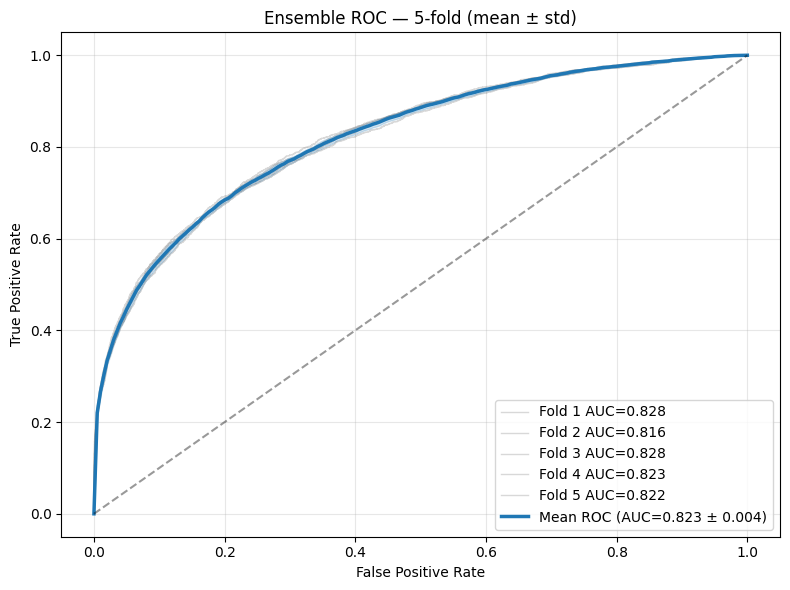

In [292]:
# Plot 5-fold ensemble ROC with variance (shaded)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import pickle

ensemble_cv_obs, ensemble_cv_probs, _ = pickle.load(open("ablationCV_GPU_5fold_results.pkl", "rb"))

mean_fpr = np.linspace(0, 1, 200)
tprs = []
aucs = []

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
# # precompute folds' val indices in same order used earlier
# val_idx_list = [val for _, val in skf.split(np.zeros(len(y)), y)]

plt.figure(figsize=(8,6))
for fold in sorted(ensemble_cv_probs.keys()):
    probs = np.asarray(ensemble_cv_probs[fold]).reshape(-1)
    # folds stored 1..K
    y_val_fold = np.asarray(ensemble_cv_obs[fold]).reshape(-1)

    fpr, tpr, _ = roc_curve(y_val_fold, probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    fold_auc = auc(fpr, tpr)
    aucs.append(fold_auc)
    plt.plot(fpr, tpr, color='gray', alpha=0.3, lw=1, label=f'Fold {fold} AUC={fold_auc:.3f}')

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='C0', lw=2.5, label=f'Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})')
plt.fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1), np.clip(mean_tpr + std_tpr, 0, 1), color='C0', alpha=0.2)
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC — 5-fold (mean ± std)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

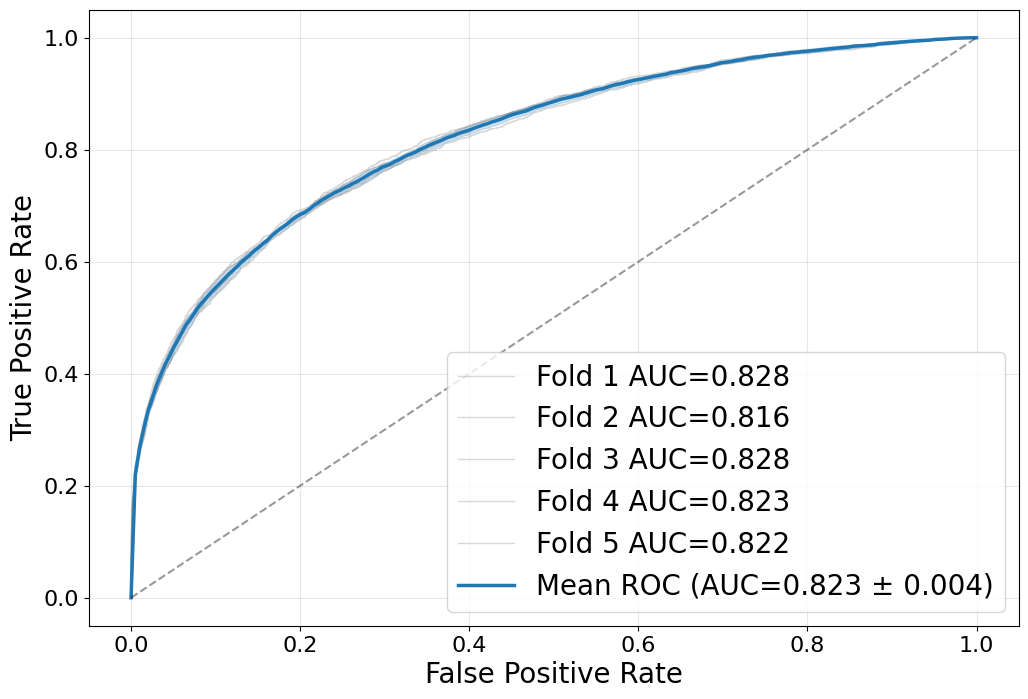

In [312]:
mean_recall = np.linspace(0, 1, 200)
pr_precisions = []
aps = []

plt.figure(figsize=(12, 8))

# ROC subplot
#plt.subplot(2,1,1)
for fold in sorted(ensemble_cv_probs.keys()):
    probs = np.asarray(ensemble_cv_probs[fold]).reshape(-1)
    y_val_fold = np.asarray(ensemble_cv_obs[fold]).reshape(-1)

    fpr, tpr, _ = roc_curve(y_val_fold, probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    fold_auc = auc(fpr, tpr)
    aucs.append(fold_auc)
    plt.plot(fpr, tpr, color='gray', alpha=0.3, lw=1, label=f'Fold {fold} AUC={fold_auc:.3f}')

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='C0', lw=2.5, label=f'Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})')
plt.fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1), np.clip(mean_tpr + std_tpr, 0, 1), color='C0', alpha=0.2)
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.rc('axes', labelsize=16)
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
#plt.title('Ensemble ROC — 5-fold (mean ± std)')
plt.legend(loc='lower right', fontsize=20)
plt.grid(alpha=0.3)

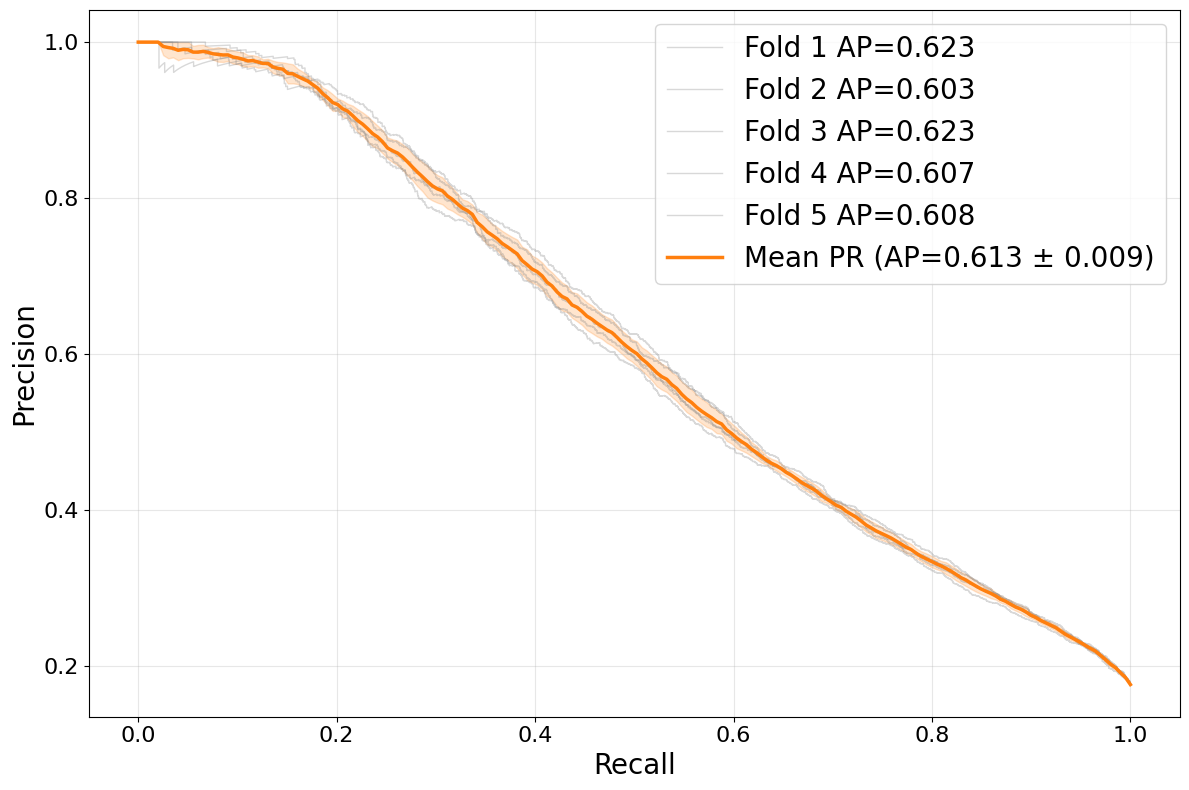

In [ ]:
# Precision-Recall subplot
plt.figure(figsize=(12, 8))

#plt.subplot(2,1,2)
for fold in sorted(ensemble_cv_probs.keys()):
    probs = np.asarray(ensemble_cv_probs[fold]).reshape(-1)
    y_val_fold = np.asarray(ensemble_cv_obs[fold]).reshape(-1)

    precision, recall, _ = precision_recall_curve(y_val_fold, probs)
    # precision_recall_curve returns precision for decreasing recall, reverse for interpolation
    prec_interp = np.interp(mean_recall, recall[::-1], precision[::-1])
    pr_precisions.append(prec_interp)
    fold_ap = average_precision_score(y_val_fold, probs)
    aps.append(fold_ap)
    plt.plot(recall, precision, color='gray', alpha=0.3, lw=1, label=f'Fold {fold} AP={fold_ap:.3f}')

mean_prec = np.mean(pr_precisions, axis=0)
std_prec = np.std(pr_precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

plt.plot(mean_recall, mean_prec, color='C1', lw=2.5, label=f'Mean PR (AP={mean_ap:.3f} ± {std_ap:.3f})')
plt.fill_between(mean_recall, np.clip(mean_prec - std_prec, 0, 1), np.clip(mean_prec + std_prec, 0, 1), color='C1', alpha=0.2)

plt.rc('axes', labelsize=16)
plt.xlabel('Recall',fontsize=20)
plt.ylabel('Precision', fontsize=20)
#plt.title('Ensemble Precision-Recall — 5-fold (mean ± std)')
#plt.title('Ensemble ROC — 5-fold (mean ± std)')
plt.legend(loc='upper right', fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5-fold CV on CPU (not recommended) 

In [7]:
def ablationCV(channel, X_trn, y_trn, X_val, models):
               
    if channel == "query":
        X_trn = X_trn[:,0,:]
        X_val = X_val[:,0,:]
    elif channel == "bm25":
        X_trn = X_trn[:,1,:]
        X_val = X_val[:,1,:]
    else:
        X_trn = X_trn[:,2,:]
        X_val = X_val[:,2,:]

    # CV XGBoost only
    ablation_probs_dict = {}
    for name, model in tqdm(models.items()):
        model.fit(X_trn, y_trn)
        ablation_probs_dict[name] = model.predict_proba(X_val)[:, 1]
    return ablation_probs_dict        

In [52]:
# # Plot ROC and Precision-Recall for ensemble_probs vs y_val
# from sklearn.metrics import roc_curve, auc, precision_recall_curve

# # Compute ROC
# fpr, tpr, _ = roc_curve(y_val, ensemble_probs)
# roc_auc = auc(fpr, tpr)

# # Compute Precision-Recall
# precision, recall, _ = precision_recall_curve(y_val, ensemble_probs)
# pr_auc = auc(recall, precision)

# import matplotlib.pyplot as plt
# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}', linewidth=2)
# plt.plot([0,1], [0,1], 'k--', alpha=0.4)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}', color='tab:orange', linewidth=2)
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()

# plt.tight_layout()
# plt.show()

# print(f"ROC AUC: {roc_auc:.4f} | PR AUC: {pr_auc:.4f}")

# run inference on OOT


In [60]:
_, x_tst_tensor, _, y_tst = pickle.load(open("x_y_trn_tst_cls_tensor.pkl", "rb"))

In [ ]:
m = xgb.XGBClassifier()
m.load_model("XGBoost_all.ubj")


X_tst = x_tst_tensor.detach().cpu().numpy() if hasattr(x_tst_tensor, "detach") else np.asarray(x_tst_tensor)
y_tst_np = y_tst.detach().cpu().numpy() if hasattr(y_tst, "detach") else np.asarray(y_tst)

# run inference on query test
X_ch = X_tst[:, 0, :].astype(np.float32)
probs = m.predict_proba(X_ch)[:, 1]

In [69]:
import importlib

In [70]:
pkgs = {'sklearn':'scikit-learn','xgboost':'xgboost'}
for mod, pipname in pkgs.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, '__version__', 'unknown')
        print(f'{mod} OK ({ver})')
    except Exception:
        print(f'{mod} MISSING -> installing {pipname}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pipname])
        m = importlib.import_module(mod)
        ver = getattr(m, '__version__', 'unknown')
        print(f'{mod} installed ({ver})')


sklearn OK (1.8.0)
xgboost OK (3.2.0)


In [68]:
all_thr, all_f1 = best_threshold_metrics(y_tst_np, probs)
all_pred = (probs >= all_thr).astype(int)

pd.DataFrame([{    
    "accuracy": accuracy_score(y_tst_np, all_pred),
    "precision": precision_score(y_tst_np, all_pred, zero_division=0),
    "recall": recall_score(y_tst_np, all_pred, zero_division=0),
    "f1": f1_score(y_tst_np, all_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_tst_np, all_pred),
    "pr_auc": average_precision_score(y_tst_np, all_pred)}]
)

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.751439,0.360813,0.564569,0.440259,0.67757,0.279096


In [72]:
# load trained models (expected files: ./xgboost_mdl/XGBoost_query.ubj, XGBoost_bm25.ubj, XGBoost_vect.ubj)
ch_files = {"query":"XGBoost_query.ubj",
            "bm25":"XGBoost_bm25.ubj",
            "vect":"XGBoost_vect.ubj"}

models = {}
for ch, fp in ch_files.items():
    m = xgb.XGBClassifier()
    m.load_model(fp)
    models[ch] = m

In [ ]:
# ensure x_tst_tensor and y_tst are numpy arrays
X_tst = x_tst_tensor.detach().cpu().numpy() if hasattr(x_tst_tensor, "detach") else np.asarray(x_tst_tensor)
y_tst_np = y_tst.detach().cpu().numpy() if hasattr(y_tst, "detach") else np.asarray(y_tst)

# reshape if needed -> (n, 3, dim)
if X_tst.ndim == 2 and X_tst.shape[1] % 3 == 0:
    dim = X_tst.shape[1] // 3
    X_tst = X_tst.reshape(X_tst.shape[0], 3, dim)

ch_idx = {"query":0, "bm25":1, "vect":2}
results = []
probs_dict = {}

for ch, model in models.items():
    X_ch = X_tst[:, ch_idx[ch], :].astype(np.float32)
    probs = model.predict_proba(X_ch)[:, 1]
    preds = (probs >= 0.5).astype(int)
    probs_dict[ch] = probs

    results.append({
        "channel": ch,
        "accuracy": accuracy_score(y_tst_np, preds),
        "precision": precision_score(y_tst_np, preds, zero_division=0),
        "recall": recall_score(y_tst_np, preds, zero_division=0),
        "f1": f1_score(y_tst_np, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_tst_np, probs),
        "pr_auc": average_precision_score(y_tst_np, probs),
    })

# get f1 weight
# normalize f1 -> weights (fallback to equal weights if all f1 == 0)
total_f1 = sum(v["f1"] for v in results)
weights = {v["channel": v["f1"] / total_f1 for v in results}


In [52]:
# ensemble by f1 weighted  
ensemble_probs = probs_dict["query"] * np.array(weights["query"]) + \
                 probs_dict["bm25"] * np.array(weights["bm25"]) + \
                 probs_dict["vect"] * np.array(weights["vect"])

# calculate best threshold
# find best threshold for ensemble (by F1)
ensemble_thr, ensemble_f1 = best_threshold_metrics(y_tst_np, ensemble_probs)
ensemble_pred = (ensemble_probs >= ensemble_thr).astype(int)

results.append({
    "channel": "f1_wt_ensemble",
    "accuracy": accuracy_score(y_tst_np, ensemble_pred),
    "precision": precision_score(y_tst_np, ensemble_pred, zero_division=0),
    "recall": recall_score(y_tst_np, ensemble_pred, zero_division=0),
    "f1": f1_score(y_tst_np, ensemble_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_tst_np, ensemble_probs),
    "pr_auc": average_precision_score(y_tst_np, ensemble_probs),
})

df_results = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
print(df_results)

          channel  accuracy  precision    recall        f1   roc_auc    pr_auc
0  f1_wt_ensemble  0.807400   0.446521  0.469113  0.457538  0.773327  0.505619
1            vect  0.811892   0.453408  0.420525  0.436347  0.762919  0.487724
2           query  0.829388   0.509823  0.379389  0.435040  0.767619  0.494389
3            bm25  0.830777   0.587973  0.075677  0.134095  0.579865  0.275019


# conclusion
* Out-of-time evaluation on future FAERS reports demonstrates that retrieval-enhanced representations improve model robustness and generalization. While query-only embeddings achieved higher accuracy (82.9%), the proposed ensemble framework yielded superior F1-score (0.458), recall (0.469), ROC-AUC (0.773), and PR-AUC (0.506). BM25 retrieval produced the highest precision (0.588) but suffered from substantially lower recall (0.076), indicating that lexical retrieval alone identifies only a small subset of severe ADRs, but is insufficient for identifying diverse severe ADR patterns. These findings suggest that combining semantic retrieval, lexical retrieval, and query representations captures complementary pharmacovigilance signals and improves future ADR severity predictionLexical retrieval identifies only a small subset of severe ADRs, but when it predicts severity, it is often correct.

In [272]:
#pickle.dump(df_results, open("ml_model_inference.pkl", "wb"))
ml_mdl_inf  = pickle.load(open("ml_model_inference.pkl", "rb"))

In [275]:
# export to latex
print(ml_mdl_inf.style.format(precision=3).hide(axis="index").to_latex())

\begin{tabular}{lrrrrrr}
channel & accuracy & precision & recall & f1 & roc_auc & pr_auc \\
f1_wt_ensemble & 0.807 & 0.447 & 0.469 & 0.458 & 0.773 & 0.506 \\
vect & 0.812 & 0.453 & 0.421 & 0.436 & 0.763 & 0.488 \\
query & 0.829 & 0.510 & 0.379 & 0.435 & 0.768 & 0.494 \\
bm25 & 0.831 & 0.588 & 0.076 & 0.134 & 0.580 & 0.275 \\
\end{tabular}



In [ ]:
#pickle.dump(probs_dict, open("ml_model_inf_probs.pkl", "wb"))

In [128]:
# Run Optuna studies
# study_rf = optuna.create_study(direction="maximize")
# study_rf.optimize(objective_rf, n_trials=16)

print("RF best params:", study_rf.best_params, "best F1:", study_rf.best_value)
pickle.dump(study_rf, open("study_rf_.pkl", "wb"))

RF best params: {'n_estimators': 427, 'max_depth': 29} best F1: 0.55


In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=24)

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_catboost, n_trials=24)

ml_# print("RF best params:", study_rf.best_params, "best F1:", study_rf.best_value)
# pickle.dump(study_rf, open("study_rf_.pkl", "wb"))
print("XGB best params:", study_xgb.best_params, "best F1:", study_xgb.best_value)
pickle.dump(study_xgb, open("study_xgb.pkl", "wb"))

print("CatBoost best params:", study_cat.best_params, "best F1:", study_cat.best_value)
pickle.dump(study_cat, open("study_cat.pkl", "wb"))

[I 2026-06-10 15:56:24,382] A new study created in memory with name: no-name-5839c338-6adb-4cb3-b9f7-dcce670f7ac8
[I 2026-06-10 17:02:41,539] Trial 0 finished with value: 0.551178203240059 and parameters: {'n_estimators': 410, 'max_depth': 22, 'learning_rate': 0.01801448580316249}. Best is trial 0 with value: 0.551178203240059.
[I 2026-06-10 17:26:54,147] Trial 1 finished with value: 0.5465815176558978 and parameters: {'n_estimators': 377, 'max_depth': 18, 'learning_rate': 0.09610249324732337}. Best is trial 0 with value: 0.551178203240059.


# compare with other DL baseline models

In [ ]:
x_binary_tensor.shape 

torch.Size([118953, 3, 1024])

In [60]:
class LSTM(nn.Module):
    """LSTM baseline for binary classification: input (B, 10, 1024) -> logits (B, 1)."""
    def __init__(self, token_dim=1024, hidden=768, num_classes=1, 
                 dropout=0.2, prior_logits=None):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=token_dim,
            hidden_size=hidden,
            num_layers=2,
            bidirectional=False,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
        if prior_logits is not None:
            with torch.no_grad():
                self.head[-1].bias.copy_(prior_logits.to(self.head[-1].bias.device))

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(x.size(0), 3, -1)
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]  # (B, hidden)
        logits = self.head(h_last)  # (B, 1)
        return logits


class BiLSTM(nn.Module):
    """BiLSTM baseline for binary classification: input (B, 3, 1024) -> logits (B, 1)."""
    def __init__(self, token_dim=1024, hidden=768, num_classes=1, 
                 dropout=0.2, prior_logits=None):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=token_dim,
            hidden_size=hidden,
            num_layers=2,
            bidirectional=True,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
        if prior_logits is not None:
            with torch.no_grad():
                self.head[-1].bias.copy_(prior_logits.to(self.head[-1].bias.device))

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(x.size(0), 3, -1)
        _, (h_n, _) = self.lstm(x)
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        logits = self.head(h_cat)
        return logits


class CNN(nn.Module):
    """CNN baseline for binary classification: input (B, 3, 1024) -> logits (B, 1)."""
    def __init__(self, token_dim=1024, hidden=768, num_classes=1,
                 dropout=0.2, prior_logits=None, num_filters=64, 
                 kernel_sizes=(3, 5, 7)):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=token_dim, out_channels=num_filters,
                      kernel_size=ks, padding=ks // 2)
            for ks in kernel_sizes
        ])
        self.bn_layers = nn.ModuleList([
            nn.BatchNorm1d(num_filters) for _ in kernel_sizes
        ])
        cnn_output_dim = num_filters * len(kernel_sizes)
        self.head = nn.Sequential(
            nn.Linear(cnn_output_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
        if prior_logits is not None:
            with torch.no_grad():
                self.head[-1].bias.copy_(prior_logits.to(self.head[-1].bias.device))

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(x.size(0), 3, -1)
        x = x.transpose(1, 2)
        conv_outputs = []
        for conv, bn in zip(self.convs, self.bn_layers):
            conv_out = conv(x)
            conv_out = bn(conv_out)
            conv_out = F.relu(conv_out)
            pooled = conv_out.mean(dim=2)
            conv_outputs.append(pooled)
        pooled = torch.cat(conv_outputs, dim=1)
        logits = self.head(pooled)
        return logits


In [ ]:
BINARY_THRESHOLD = 0.5

In [104]:
def tune_binary_threshold_recall(
    y_true, probs, min_precision=None, thresholds=None,
):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.91, 0.01)

    best_threshold = 0.5
    best_rec = -1.0
    best_prec = 0.0

    for t in thresholds:
        pred = (probs >= t).astype(float)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if min_precision is None:
            if rec > best_rec:
                best_threshold, best_prec, best_rec = t, prec, rec
        elif prec >= min_precision and rec > best_rec:
            best_threshold, best_prec, best_rec = t, prec, rec

    return float(best_threshold), float(best_prec), float(best_rec)

def eval_binary_loader(model, loader, criterion, threshold=None):
    """Evaluate binary classification model on a loader.
    If threshold is None, tune threshold by maximizing F1 via tune_binary_threshold_f1().
    Returns: (avg_loss, f1, recall, pred_density, y_probs, y_true)
    """
    model.eval()
    total_loss, n = 0.0, 0
    y_true, y_probs = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = torch.as_tensor(y_batch, dtype=torch.float32, device=device).unsqueeze(1)

            logits = model(x_batch)  # (B, 1)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            y_batch_np = y_batch.cpu().numpy().reshape(-1)

            bs = x_batch.size(0)
            total_loss += loss.item() * bs
            n += bs

            y_true.append(y_batch_np)
            y_probs.append(probs)

    if n == 0:
        return 0.0, 0.0, 0.0, 0.0, np.array([]), np.array([])

    y_true = np.concatenate([arr.reshape(-1) for arr in y_true])
    y_probs = np.concatenate([arr.reshape(-1) for arr in y_probs])

    # Tune threshold for best F1 if not provided
    if threshold is None:
        thr, _ = tune_binary_threshold_f1(y_true, y_probs, thresholds=np.arange(0.05, 0.91, 0.01))
        threshold = float(thr)

    preds = (y_probs >= threshold).astype(int)
    f1 = f1_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    pred_density = preds.mean()

    return (total_loss / n, f1, rec, pred_density, y_probs, y_true)

# def eval_binary_loader(model, loader, criterion, threshold=0.5):
#     """Evaluate binary classification model on a loader."""
#     model.eval()
#     total_loss, n = 0.0, 0
#     y_true, y_pred, y_probs = [], [], []
    
#     with torch.no_grad():
#         for x_batch, y_batch in loader:
#             x_batch = x_batch.to(device)
#             y_batch = torch.as_tensor(y_batch, dtype=torch.float32, device=device).unsqueeze(1)
                        
#             logits = model(x_batch)  # (B, 1)
            
#             loss = criterion(logits, y_batch)
#             probs = torch.sigmoid(logits)
#             pred = (probs >= threshold).float()
            
#             bs = x_batch.size(0)
#             total_loss += loss.item() * bs
#             n += bs
            
#             y_true.append(y_batch.cpu().numpy())
#             y_pred.append(pred.cpu().numpy())
#             y_probs.append(probs.cpu().numpy())
    
#     y_true = np.concatenate([arr.reshape(-1) for arr in y_true])
#     y_pred = np.concatenate([arr.reshape(-1) for arr in y_pred])
#     y_probs = np.concatenate([arr.reshape(-1) for arr in y_probs])

#     return (
#         total_loss / n,
#         f1_score(y_true, y_pred, average="binary", zero_division=0),
#         recall_score(y_true, y_pred, average="binary", zero_division=0),
#         y_pred.mean(),
#         y_probs,
#         y_true,
#     )

def collect_binary_probs(model, loader):
    """Collect true labels and predicted probabilities for binary classification."""
    model.eval()
    y_true, probs = [], []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            logits = model(x_batch.to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy())
            y_true.append(
                y_batch.numpy() if isinstance(y_batch, np.ndarray) else y_batch.cpu().numpy()
            )
    
    y_true = np.concatenate([arr.reshape(-1) for arr in y_true])
    probs = np.concatenate([arr.reshape(-1) for arr in probs])

    return y_true, probs


def binary_metrics(y_true, y_pred, y_probs=None, label=""):
    """Compute and print binary classification metrics including ROC-AUC and PR-AUC."""
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    
    print(f"{label}")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    if y_probs is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_probs)
            pr_auc = average_precision_score(y_true, y_probs)
            print(f"  ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | Pred density: {y_pred.mean():.4f}")
            return prec, rec, f1, acc, roc_auc, pr_auc
        except Exception as e:
            print(f"  ⚠ Could not compute AUC: {e}")
    
    print(f"  Pred density: {y_pred.mean():.4f}")
    return prec, rec, f1, acc, None, None


def tune_binary_threshold_recall_floor(
    y_true, probs, precision_floor=0.50, thresholds=None,
):
    """Maximize recall subject to precision >= precision_floor."""
    if thresholds is None:
        thresholds = np.arange(0.05, 0.91, 0.01)

    best_threshold = None
    best_rec = -1.0
    best_prec = 0.0
    rows = []

    for t in thresholds:
        pred = (probs >= t).astype(float)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        rows.append((t, prec, rec))

        if prec >= precision_floor and rec > best_rec:
            best_threshold = float(t)
            best_prec = prec
            best_rec = rec

    if best_threshold is not None:
        return best_threshold, best_prec, best_rec, rows

    # Fallback: choose the threshold with highest precision, then highest recall
    best_threshold, best_prec, best_rec = max(
        rows, key=lambda row: (row[1], row[2])
    )
    print(
        f"⚠ Warning: no threshold met precision floor {precision_floor:.2f}; "
        f"using max-precision fallback: t={best_threshold:.3f}, "
        f"prec={best_prec:.4f}, rec={best_rec:.4f}"
    )
    return float(best_threshold), best_prec, best_rec, rows


def tune_binary_threshold_f1(y_true, y_probs, thresholds=None):
    """Find threshold that maximizes F1 score."""
    if thresholds is None:
        thresholds = np.arange(0.15, 0.55, 0.05)
    
    best_threshold, best_f1 = 0.5, 0.0
    
    for t in thresholds:
        f1 = f1_score(y_true, (y_probs >= t).astype(float), zero_division=0)
        if f1 > best_f1:
            best_f1, best_threshold = f1, float(t)
    
    return best_threshold, best_f1


def train_single_binary_model(
    model,
    train_loader,
    val_loader,
    criterion,
    epochs=50,
    lr=2e-4,
    weight_decay=1e-4,
    tag="model",
    patience=10,
):
    """Train binary classification model with early stopping."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state, best_val_score = None, -1.0
    epochs_no_improve = 0

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss, n = 0.0, 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = torch.as_tensor(y_batch, dtype=torch.float32, device=device).view(-1, 1)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_batch)
            if logits.shape[0] != y_batch.shape[0]:
                raise ValueError(
                    f"Batch size mismatch: logits {tuple(logits.shape)} vs labels {tuple(y_batch.shape)}. "
                    "Check model uses batch_first=True for LSTM/attention."
                )

            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            bs = x_batch.size(0)
            tr_loss += loss.item() * bs
            n += bs

        tr_loss /= max(n, 1)

        va_loss, va_f1, va_rec, va_pred_density, va_probs, va_true = eval_binary_loader(
            model, val_loader, criterion, threshold=0.50
        )

        if va_rec > best_val_score:
            best_val_score = va_rec
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"[{tag}] ep {ep:02d}/{epochs} | "
            f"tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} "
            f"va_f1={va_f1:.4f} va_rec={va_rec:.4f} pred_density={va_pred_density:.4f} "
            f"(patience: {epochs_no_improve}/{patience})"
        )

        if epochs_no_improve >= patience:
            print(f"[{tag}] Early stopping at epoch {ep} (no improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    y_val, val_probs = collect_binary_probs(model, val_loader)

    # Candidate threshold: maximize F1
    cand_t, cand_f1 = tune_binary_threshold_f1(
        y_val,
        val_probs,
        thresholds=np.arange(0.05, 0.91, 0.01),
    )

    # Ensure precision floor of at least 0.5; fall back to recall-floor tuner if needed
    prec_at_cand = precision_score(y_val, (val_probs >= cand_t).astype(int), zero_division=0)
    if prec_at_cand >= 0.5:
        final_t = float(cand_t)
        final_f1 = float(cand_f1)
        print(f"[{tag}] F1-optimal threshold {final_t:.3f} meets precision floor (prec={prec_at_cand:.4f})")
    else:
        print(
            f"[{tag}] F1-optimal threshold {cand_t:.3f} has precision {prec_at_cand:.4f} < 0.50; "
            "falling back to recall-maximizer with precision floor 0.50"
        )
        final_t, final_prec, final_rec, _ = tune_binary_threshold_recall_floor(
            y_val, val_probs, precision_floor=0.50, thresholds=np.arange(0.05, 0.91, 0.01)
        )
        final_f1 = f1_score(y_val, (val_probs >= final_t).astype(int), zero_division=0)

    y_val_pred = (val_probs >= final_t).astype(float)

    prec, rec, f1, acc, roc_auc, pr_auc = binary_metrics(
        y_val, y_val_pred, val_probs, label=f"{tag} @t={final_t:.2f}"
    )

    print(
        f"\n[{tag}] Final threshold: {final_t:.3f} (f1={final_f1:.4f}) | "
        f"precision={prec:.4f}, recall={rec:.4f}"
    )

    # save model best status
    torch.save(model.state_dict(), f"{tag}_weights.pth")

    return {
        "model": model,
        "val_accuracy": float(acc),
        "val_precision": float(prec),
        "val_recall": float(rec),
        "val_f1": float(f1),
        "val_roc_auc": float(roc_auc) if roc_auc is not None else None,
        "val_pr_auc": float(pr_auc) if pr_auc is not None else None,
        "threshold": float(final_t),
    }


In [61]:
TOKEN_DIM = 1024  # should be 1052 based on earlier print
binary_classes = 2

#--- Build models for direct comparison with HybridRAGBinaryModel()
hybrid_model = HybridRAGBinaryModel(
    input_features=1024,
    hidden_dim=768,  # increased from 256
    dropout=0.2,     
    num_heads=4
).to(device)

lstm_model = LSTM(
    token_dim=TOKEN_DIM,
    hidden=768,
    dropout=0.2,
).to(device)

bilstm_model = BiLSTM(
    token_dim=TOKEN_DIM,
    hidden=768,
    dropout=0.2,    
).to(device)

cnn_model = CNN(
    token_dim=TOKEN_DIM,
    hidden=768,
    dropout=0.2,
    num_filters=64,
    kernel_sizes=(3, 5, 7)
).to(device)

MODEL_ZOO = {
    "Hybrid_model": hybrid_model,
    "LSTM_baseline": lstm_model,
    "BiLSTM_baseline": bilstm_model,    
    "CNN_Baseline": cnn_model,
}

In [55]:
#criterion = BalancedBinaryCrossEntropy(pos_weight=pos_weight)

In [105]:
# Train all 7 models with same data and criterion for apples-to-apples comparison
comparison_rows = []
for name, model in MODEL_ZOO.items():
    result = train_single_binary_model(
        model,
        train_loader_1hot,
        val_loader_1hot,
        criterion, #customized criterion
        epochs=50,
        lr=2e-4,
        weight_decay=1e-4,        
        tag=name,
        patience=10,
    )
    comparison_rows.append(
        {
            "model": name,            
            "val_precision": result["val_precision"],
            "val_recall": result["val_recall"],
            "val_f1": result["val_f1"],
            "val_accuracy": result["val_accuracy"],
            'val_roc_auc': result["val_roc_auc"],   
            'val_pr_auc': result["val_pr_auc"],
            "threshold": result["threshold"],
        }
    )

[Hybrid_model] ep 01/50 | tr_loss=0.7396 va_loss=0.9341 va_f1=0.5014 va_rec=0.6226 pred_density=0.2650 (patience: 0/10)
[Hybrid_model] ep 02/50 | tr_loss=0.6818 va_loss=0.9709 va_f1=0.4960 va_rec=0.6656 pred_density=0.3009 (patience: 0/10)
[Hybrid_model] ep 03/50 | tr_loss=0.6430 va_loss=1.0266 va_f1=0.5013 va_rec=0.6709 pred_density=0.2996 (patience: 0/10)
[Hybrid_model] ep 04/50 | tr_loss=0.6078 va_loss=1.0478 va_f1=0.4914 va_rec=0.6741 pred_density=0.3115 (patience: 0/10)
[Hybrid_model] ep 05/50 | tr_loss=0.5837 va_loss=1.0880 va_f1=0.4992 va_rec=0.6425 pred_density=0.2812 (patience: 1/10)
[Hybrid_model] ep 06/50 | tr_loss=0.5523 va_loss=1.1209 va_f1=0.4971 va_rec=0.6791 pred_density=0.3095 (patience: 0/10)
[Hybrid_model] ep 07/50 | tr_loss=0.5208 va_loss=1.1748 va_f1=0.5036 va_rec=0.6510 pred_density=0.2832 (patience: 1/10)
[Hybrid_model] ep 08/50 | tr_loss=0.4941 va_loss=1.3058 va_f1=0.5020 va_rec=0.5781 pred_density=0.2328 (patience: 2/10)
[Hybrid_model] ep 09/50 | tr_loss=0.4749

In [106]:
comparison_df = pd.DataFrame(comparison_rows).sort_values("val_f1", ascending=False)
print("\nValidation comparison (same split/loss/training):")
display(comparison_df)


Validation comparison (same split/loss/training):


,model,val_precision,val_recall,val_f1,val_accuracy,val_roc_auc,val_pr_auc,threshold
0,Hybrid_model,0.517547,0.519388,0.518466,0.827613,0.806429,0.581908,0.75
3,CNN_Baseline,0.508136,0.488794,0.498277,0.824116,0.799049,0.553862,0.70
2,BiLSTM_baseline,0.502979,0.360370,0.419896,0.822082,0.768826,0.493532,0.70
1,LSTM_baseline,0.507748,0.349698,0.414156,0.823227,0.771628,0.501577,0.74


In [107]:
comparison_df = comparison_df.iloc[:,:6]

In [ ]:
Ensemble_XGBoost = pd.read_clipboard()

In [88]:
Ensemble_XGBoost.drop(["Model"], axis = 1, inplace = True)

In [90]:
Ensemble_XGBoost

,Model,Accuracy,F1,Recall,Precision,AUC
0,Ensemble_XGBoost,0.837338,0.550816,0.564592,0.537697,0.829078


In [89]:
Ensemble_XGBoost.columns = ["Model","Accuracy","F1","Recall","Precision","AUC"]

In [108]:
comparison_df.columns = ["Model", "Precision", "F1", "Recall","Accuracy", "AUC"]

In [109]:
comparison_df

,Model,Precision,F1,Recall,Accuracy,AUC
0,Hybrid_model,0.517547,0.519388,0.518466,0.827613,0.806429
3,CNN_Baseline,0.508136,0.488794,0.498277,0.824116,0.799049
2,BiLSTM_baseline,0.502979,0.360370,0.419896,0.822082,0.768826
1,LSTM_baseline,0.507748,0.349698,0.414156,0.823227,0.771628


In [110]:
comparison_df = comparison_df.loc[:,Ensemble_XGBoost.columns]

In [111]:
comp_df = pd.concat([comparison_df, Ensemble_XGBoost], ignore_index=True)

In [258]:
comp_df = pd.read_csv("ml_dl_comp_df.csv")
comp_df.sort_values("F1", ascending=False)

,Model,Accuracy,F1,Recall,Precision,AUC
4,Ensemble_XGBoost,0.837338,0.550816,0.564592,0.537697,0.829078
0,Hybrid_model,0.827613,0.519388,0.518466,0.517547,0.806429
1,CNN_Baseline,0.824116,0.488794,0.498277,0.508136,0.799049
2,BiLSTM_baseline,0.822082,0.360370,0.419896,0.502979,0.768826
3,LSTM_baseline,0.823227,0.349698,0.414156,0.507748,0.771628


In [260]:
# convert comp_df to latex
print(comp_df.style.format(precision=2).hide(axis="index").to_latex())

\begin{tabular}{lrrrrr}
Model & Accuracy & F1 & Recall & Precision & AUC \\
Hybrid_model & 0.83 & 0.52 & 0.52 & 0.52 & 0.81 \\
CNN_Baseline & 0.82 & 0.49 & 0.50 & 0.51 & 0.80 \\
BiLSTM_baseline & 0.82 & 0.36 & 0.42 & 0.50 & 0.77 \\
LSTM_baseline & 0.82 & 0.35 & 0.41 & 0.51 & 0.77 \\
Ensemble_XGBoost & 0.84 & 0.55 & 0.56 & 0.54 & 0.83 \\
\end{tabular}



In [ ]:
comp_df.to_csv("ml_dl_comp_df.csv", index = False)

# get LLM inference in validation

In [ ]:
def ensemble_probs_(probs_list, weights=None):
    """
    probs_list: list/array of shape (n_samples,) or (n_models, n_samples)
    weights: list of length n_models or None (equal weights)
    returns: array of shape (n_samples,)
    """
    arr = np.vstack(probs_list) if len(np.array(probs_list).shape) == 2 else np.array(probs_list)
    if arr.ndim == 1:
        return arr
    if weights is None:
        weights = np.ones(arr.shape[0]) / arr.shape[0]
    weights = np.array(weights) / np.sum(weights)
    return (weights[:, None] * arr).sum(axis=0)

def sweep_thresholds(probs, y_true, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 1001)
    best_f1 = -1; best_f1_thr = None
    best_recall = -1; best_recall_thr = None
    metrics = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        p = precision_score(y_true, preds, zero_division=0)
        r = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)
        metrics.append((t, p, r, f1))
        if f1 > best_f1:
            best_f1 = f1; best_f1_thr = t
        if r > best_recall:
            best_recall = r; best_recall_thr = tdf_res
    return {
        "metrics": metrics,               # list of (threshold, precision, recall, f1)
        "best_f1_threshold": best_f1_thr,
        "best_f1": best_f1,
        "best_recall_threshold": best_recall_thr,
        "best_recall": best_recall
    }

def optimize_thresholds(probs_list, y_true, weights=None, thresholds=None, min_precision=None):
    """
    Returns thresholds that maximize F1 and maximize recall subject to min_precision (if provided).
    probs_list: list of model probability arrays (each shape (n_samples,))
    min_precision: optional float in [0,1] to require at least this precision when maximizing recall
    """
    probs = ensemble_probs_(probs_list, weights)
    sweep = sweep_thresholds(probs, y_true, thresholds)
    best_f1_thr = sweep["best_f1_threshold"]
    best_f1 = sweep["best_f1"]

    # choose threshold maximizing recall subject to min_precision if provided
    best_rec_thr = sweep["best_recall_threshold"]
    best_rec = sweep["best_recall"]
    if min_precision is not None:
        candidates = [(t, p, r, f1) for (t, p, r, f1) in sweep["metrics"] if p >= min_precision]
        if candidates:
            # choose candidate with max recall, break ties by higher f1 then lower threshold
            candidates.sort(key=lambda x: (x[2], x[3], -x[0]), reverse=True)
            best_rec_thr, _, best_rec, _ = candidates[0]
        else:
            best_rec_thr, best_rec = None, None

    return {
        "ensemble_probs": probs,
        "best_f1_threshold": best_f1_thr,
        "best_f1": best_f1,
        "best_recall_threshold": best_rec_thr,
        "best_recall": best_rec,
        "metrics": sweep["metrics"]
    }

# run inference on OOT (test) with DL models

In [54]:
(_, x_tst_tensor, _, y_tst) = pickle.load(open("x_y_trn_tst_cls_tensor.pkl", "rb"))

In [59]:
x_tst_tensor.shape

torch.Size([40296, 3, 1024])

In [97]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

device = "cuda" if torch.cuda.is_available() else "cpu"


In [114]:
# instantiate models (must match training configuration)
TOKEN_DIM = 1024
hybrid_model = HybridRAGBinaryModel(input_features=TOKEN_DIM, hidden_dim=768, dropout=0.2, num_heads=4).to(device)
lstm_model = LSTM(token_dim=TOKEN_DIM, hidden=768, dropout=0.2).to(device)
bilstm_model = BiLSTM(token_dim=TOKEN_DIM, hidden=768, dropout=0.2).to(device)
cnn_model = CNN(token_dim=TOKEN_DIM, hidden=768, dropout=0.2, num_filters=64, kernel_sizes=(3,5,7)).to(device)

models = {
    "Hybrid_model": (hybrid_model, "Hybrid_model_weights.pth"),
    "LSTM_baseline": (lstm_model, "LSTM_baseline_weights.pth"),
    "BiLSTM_baseline": (bilstm_model, "BiLSTM_baseline_weights.pth"),
    "CNN_Baseline": (cnn_model, "CNN_Baseline_weights.pth"),
}

# prepare test arrays
X_tst = x_tst_tensor.detach().cpu() if hasattr(x_tst_tensor, "detach") else torch.tensor(x_tst_tensor)
y_tst_np = y_tst.detach().cpu().numpy() if hasattr(y_tst, "detach") else np.asarray(y_tst)
test_ds = TensorDataset(X_tst, torch.tensor(y_tst_np, dtype=torch.long))
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False, num_workers=2, pin_memory=True)


In [115]:
results = []
OUTDIR = "./"
for name, (mdl, fname) in models.items():
    fp = fname
    if not os.path.exists(fp):
        print(f"⚠ {fp} not found, skipping {name}")
        continue

    # load weights
    state = torch.load(fp, map_location=device)
    try:
        mdl.load_state_dict(state)
    except Exception:
        # support if entire checkpoint dict saved
        mdl.load_state_dict(state if isinstance(state, dict) else state["model_state_dict"])

    mdl.eval()
    y_true_list, probs_list = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            logits = mdl(Xb)
            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            probs_list.append(probs)
            y_true_list.append(yb.numpy().reshape(-1))
    probs_all = np.concatenate(probs_list)
    y_true_all = np.concatenate(y_true_list)

    # find best threshold by F1 on test (reporting only)
    best_thr, best_f1 = best_threshold_metrics(y_true_all, probs_all)
    preds = (probs_all >= best_thr).astype(int)

    metrics = {
        "model": name,
        "threshold": float(best_thr),
        "accuracy": float(accuracy_score(y_true_all, preds)),
        "precision": float(precision_score(y_true_all, preds, zero_division=0)),
        "recall": float(recall_score(y_true_all, preds, zero_division=0)),
        "f1": float(f1_score(y_true_all, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true_all, probs_all)),
        "pr_auc": float(average_precision_score(y_true_all, probs_all)),
    }
    results.append(metrics)

    # save preds + probs
    out = {"y_true": y_true_all, "probs": probs_all, "preds": preds, "threshold": best_thr, "metrics": metrics}
    pickle.dump(out, open(os.path.join(OUTDIR, f"{name}_test_pred.pkl"), "wb"))



In [116]:
# summary
df_res = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
df_res

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,CNN_Baseline,0.60,0.765337,0.375515,0.535904,0.441597,0.754668,0.466944
1,Hybrid_model,0.65,0.779110,0.390905,0.494052,0.436467,0.746638,0.463462
2,LSTM_baseline,0.63,0.745186,0.346114,0.530457,0.418902,0.742541,0.437810
3,BiLSTM_baseline,0.59,0.740421,0.341292,0.536764,0.417270,0.740227,0.431560


In [117]:
df_res.to_csv("DL_oot.csv", index = False)

# to-do list: gap
* imbalanced data/input
* do ablation of features
* propose reasoning path

# More focus on:
* FP and FN analysis to understand model behavior and failure modes
* interpretability: which tokens/features are most important for predictions? SHAP/LIME/attention visualization?
* error analysis: look at cases where models disagree or fail, and see if there are patterns

# try LLM and LLM+RAG
* is our method better than LLM based baseline 


# Conclusion: 
* BGE-M3 has already encoded token relationships using transformers.

# save evaluation on baseline models 

In [93]:
comp_df.to_csv("baseline_model_comparison_results.csv", index=False)

In [262]:
#ft_metrics.to_csv("ft_metrics.csv", index = False)
ft_metrics = pd.read_csv('ft_metrics.csv')
ft_metrics

,Model,Accuray,F1 Score,Recall,Precision,ROC AUC
0,Llama-3.2-3B Base,0.733522,0.206356,0.200086,0.213032,0.522655
1,Llama-3.2-3B Finetuned,0.252010,0.278423,0.833453,0.167127,0.481854
2,Qwen-3.5-0.8B Base,0.207490,0.282859,0.902680,0.167705,0.482298
3,Qwen-3.5-0.8B Finetuned,0.828445,0.349365,0.266017,0.508772,0.606117


In [263]:
comp_df = pd.read_csv("baseline_model_comparison_results.csv")
comp_df.columns = ft_metrics.columns
comp_df

,Model,Accuray,F1 Score,Recall,Precision,ROC AUC
0,Hybrid_model,0.811022,0.475864,0.568125,0.517918,0.799011
1,CNN_Baseline,0.809942,0.471632,0.529349,0.498827,0.795920
2,BiLSTM_baseline,0.792715,0.436007,0.545358,0.484590,0.787069
3,LSTM_baseline,0.777142,0.409623,0.560299,0.473257,0.782907
4,XGBoost,0.819095,0.488785,0.525369,0.506417,0.802528
5,RandomForest,0.827613,0.512589,0.490824,0.501471,0.800123


In [265]:
comp_all = pd.concat([comp_df, ft_metrics.iloc[[1,3],:]], ignore_index=True)
comp_all


,Model,Accuray,F1 Score,Recall,Precision,ROC AUC
0,Hybrid_model,0.811022,0.475864,0.568125,0.517918,0.799011
1,CNN_Baseline,0.809942,0.471632,0.529349,0.498827,0.795920
2,BiLSTM_baseline,0.792715,0.436007,0.545358,0.484590,0.787069
3,LSTM_baseline,0.777142,0.409623,0.560299,0.473257,0.782907
4,XGBoost,0.819095,0.488785,0.525369,0.506417,0.802528
5,RandomForest,0.827613,0.512589,0.490824,0.501471,0.800123
6,Llama-3.2-3B Finetuned,0.252010,0.278423,0.833453,0.167127,0.481854
7,Qwen-3.5-0.8B Finetuned,0.828445,0.349365,0.266017,0.508772,0.606117


In [ ]:
comp_all_auc = comp_all.sort_values("ROC AUC", ascending=False)

In [268]:
comp_all_auc.to_csv("all_model_comparison_results.csv", index=False)

In [271]:
print(comp_all_auc.style.format(precision=3).hide(axis="index").to_latex())

\begin{tabular}{lrrrrr}
Model & Accuray & F1 Score & Recall & Precision & ROC AUC \\
XGBoost & 0.819 & 0.489 & 0.525 & 0.506 & 0.803 \\
RandomForest & 0.828 & 0.513 & 0.491 & 0.501 & 0.800 \\
Hybrid_model & 0.811 & 0.476 & 0.568 & 0.518 & 0.799 \\
CNN_Baseline & 0.810 & 0.472 & 0.529 & 0.499 & 0.796 \\
BiLSTM_baseline & 0.793 & 0.436 & 0.545 & 0.485 & 0.787 \\
LSTM_baseline & 0.777 & 0.410 & 0.560 & 0.473 & 0.783 \\
Qwen-3.5-0.8B Finetuned & 0.828 & 0.349 & 0.266 & 0.509 & 0.606 \\
Llama-3.2-3B Finetuned & 0.252 & 0.278 & 0.833 & 0.167 & 0.482 \\
\end{tabular}



# run 5_fold CV

In [102]:
# 5-fold CV for best model (HybridRAGBinaryModel) to get more robust estimate of generalization performance
from sklearn.model_selection import KFold

def train_and_evaluate_cv(model_class, X, y, criterion, n_splits=5, **model_kwargs):    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=1234)
    cv_results = []
    cv_predictions = []  # Store predictions for each fold
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n--- Fold {fold + 1}/{n_splits} ---")
        
        X_train_fold = torch.tensor(X[train_idx], dtype=torch.float32)
        y_train_fold = torch.tensor(y[train_idx], dtype=torch.float32)
        X_val_fold = torch.tensor(X[val_idx], dtype=torch.float32)
        y_val_fold = torch.tensor(y[val_idx], dtype=torch.float32)
        
        train_loader_fold = DataLoader(
            TensorDataset(X_train_fold, y_train_fold),
            batch_size=2048,
            shuffle=True,
            num_workers=2,
            pin_memory=True,
        )
        val_loader_fold = DataLoader(
            TensorDataset(X_val_fold, y_val_fold),
            batch_size=2048,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )
        
        model = model_class(**model_kwargs).to(device)
        
        result = train_single_binary_model(
            model,
            train_loader_fold,
            val_loader_fold,
            criterion,
            epochs=50,
            lr=1e-4,
            weight_decay=1e-4,
            tag=f"Fold {fold + 1}",
            patience=10,
        )
        
        # Collect predictions on validation fold
        y_val_true, y_val_probs = collect_binary_probs(model, val_loader_fold)
        y_val_pred = (y_val_probs >= result["threshold"]).astype(np.int64)
        
        cv_predictions.append({
            "fold": fold + 1,
            "val_idx": val_idx,
            "y_true": y_val_true,
            "y_probs": y_val_probs,
            "y_pred": y_val_pred,
        })
        
        cv_results.append(result)
    
    return cv_results, cv_predictions

In [96]:
cv_results, cv_preds = train_and_evaluate_cv(
    HybridRAGBinaryModel,
    x_trn_tensor.detach().cpu().numpy().reshape(x_trn_tensor.shape[0], -1),
    y_trn.detach().cpu().numpy(),
    criterion,
    n_splits=5,
    input_features=1024,
    hidden_dim=768,
    dropout=0.2,
    num_heads=4,
)


--- Fold 1/5 ---
[Fold 1] ep 01/50 | tr_loss=1.0146 va_loss=0.9575 va_f1=0.3659 va_rec=0.8999 pred_density=0.6793 (patience: 0/5)
[Fold 1] ep 02/50 | tr_loss=0.9574 va_loss=0.9297 va_f1=0.3567 va_rec=0.9362 pred_density=0.7366 (patience: 1/5)
[Fold 1] ep 03/50 | tr_loss=0.9351 va_loss=0.9124 va_f1=0.3657 va_rec=0.9230 pred_density=0.7018 (patience: 2/5)
[Fold 1] ep 04/50 | tr_loss=0.9230 va_loss=0.9180 va_f1=0.3581 va_rec=0.9424 pred_density=0.7389 (patience: 3/5)
[Fold 1] ep 05/50 | tr_loss=0.9000 va_loss=0.9072 va_f1=0.3734 va_rec=0.9215 pred_density=0.6822 (patience: 0/5)
[Fold 1] ep 06/50 | tr_loss=0.8880 va_loss=0.8991 va_f1=0.3741 va_rec=0.9168 pred_density=0.6763 (patience: 0/5)
[Fold 1] ep 07/50 | tr_loss=0.8760 va_loss=0.8938 va_f1=0.3857 va_rec=0.9006 pred_density=0.6362 (patience: 0/5)
[Fold 1] ep 08/50 | tr_loss=0.8523 va_loss=0.8973 va_f1=0.3806 va_rec=0.9072 pred_density=0.6531 (patience: 1/5)
[Fold 1] ep 09/50 | tr_loss=0.8340 va_loss=0.9127 va_f1=0.3981 va_rec=0.8761 p

In [98]:
# Aggregate across all folds
y_all_true = np.concatenate([pred["y_true"] for pred in cv_preds])
y_all_pred = np.concatenate([pred["y_pred"] for pred in cv_preds])
y_all_probs = np.concatenate([pred["y_probs"] for pred in cv_preds])

print(f"\n5-Fold CV aggregated metrics:")
binary_metrics(y_all_true, y_all_pred, y_all_probs, label="5-Fold CV Overall")

# Save predictions
pickle.dump(cv_preds, open("cv_predictions_binary.pkl", "wb"))
pickle.dump(cv_results, open("cv_results_binary.pkl", "wb"))


5-Fold CV aggregated metrics:
5-Fold CV Overall
  Accuracy: 0.7801 | Precision: 0.4162 | Recall: 0.6080 | F1: 0.4941
  ROC-AUC: 0.7865 | PR-AUC: 0.5498 | Pred density: 0.2580


In [6]:
cv_preds = pickle.load(open("cv_predictions_binary.pkl", "rb"))
cv_results = pickle.load(open("cv_results_binary.pkl", "rb"))

In [12]:
# test on holdout set (oot_X_raw[trn_idx:]) using best model from CV
best_cv_fold = max(cv_results, key=lambda x: x["val_f1"])
print(f"\nBest CV fold with val F1: {best_cv_fold['val_f1']:.4f}")

best_model = HybridRAGBinaryModel(
    input_features=1024,
    hidden_dim=768,
    dropout=0.2,
    num_heads=4
).to(device)
best_model.load_state_dict(best_cv_fold["model"].state_dict())    
best_model.eval()

# Process test set in batches to avoid OOM
test_loader = DataLoader(
    TensorDataset(x_tst_tensor, y_tst),
    batch_size=2048,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

y_test_true, y_test_pred, y_test_probs = [], [], []
best_threshold = best_cv_fold["threshold"]

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits_batch = best_model(X_batch)
        probs_batch = torch.sigmoid(logits_batch).cpu().numpy().reshape(-1)
        preds_batch = (probs_batch >= best_threshold).astype(np.int64)
        
        y_test_true.append(y_batch.numpy())
        y_test_pred.append(preds_batch)
        y_test_probs.append(probs_batch)

y_test_true = np.concatenate(y_test_true)
y_test_pred = np.concatenate(y_test_pred)
y_test_probs = np.concatenate(y_test_probs)

print(f"\nHoldout test set metrics:")
binary_metrics(y_test_true, y_test_pred, y_test_probs, label="Holdout Test Set")


Best CV fold with val F1: 0.5162

Holdout test set metrics:
Holdout Test Set
  Accuracy: 0.7794 | Precision: 0.3873 | Recall: 0.4715 | F1: 0.4253
  ROC-AUC: 0.7335 | PR-AUC: 0.4540 | Pred density: 0.2108


(0.38733223451848364,
 0.47154937652286083,
 0.42531187382845326,
 0.7793577526305341,
 0.7334747606369693,
 0.45404825241619573)

# Ablation studies are critical
* No retrieval just query
* With BM25 retrievals 
* with Dense retreivals
* With Hybrid retrievals